In [1]:
### This is for calculating 

import pandas as pd
df_scores = pd.read_excel(r'analysed_data/ROW_DATA_Sonja_add_MV_ECMO_and_ECMO_LPS.xlsx',sheet_name='Total Score',engine='openpyxl')
df_scores_Ct_MV_LP = df_scores[0:19]

df_scores

,PDF/ EXCEL correspodent Data,(sanned slide) Sample Name,Group,Sandra Intermediate,Martin Intermediate,Sinem novice,Oscar Expert,Deniz Expert,min,max,Median,Average,STDEV.P
0,10,9,Control,3,12,4,11,6,3,12,6,7.2,3.655133
1,15,14,Control,3,7,8,11,18,3,18,8,9.4,5.003998
2,16,15,Control,2,9,10,2,5,2,10,5,5.6,3.382307
3,17,16,Control,2,14,6,8,7,2,14,7,7.4,3.878144
4,18,17,Control,3,11,0,5,6,0,11,5,5.0,3.633180
5,19,18,Control,2,9,4,7,15,2,15,7,7.4,4.498889
6,20,19,Control,10,12,9,18,16,9,18,12,13.0,3.464102
7,21,20,Control,3,15,4,9,10,3,15,9,8.2,4.354308
8,23,28,Control,0,10,1,9,7,0,10,7,5.4,4.127953
9,27,26,Control,0,12,10,2,2,0,12,2,5.2,4.833218


### In the nect cell I just print the summary of layers in EffnetB4 model

In [2]:
from tensorflow.keras.applications import VGG16
x = VGG16(weights = 'imagenet',include_top=False)
x.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, None, None, 128)   0     

### Here we train more layers from the base model to see if this improves the performance or not

First we train batch normalization (-2),  a concolutional layer (-3) and both from EffnetB4 model (-2,-3)

In [ ]:
 block5_conv1 (Conv2D)       (None, None, None, 512)   2359808   
                                                                 
 block5_conv2 (Conv2D)       (None, None, None, 512)   2359808   
                                                                 
 block5_conv3 (Conv2D)       (None, None, None, 512)   2359808   
                                                                 
 block5_pool (MaxPooling2D)  (None, None, None, 512)   0         
                                                                 
=================================================================
Total params: 14,714,688
Trainable params: 14,714,688
Non-trainable params: 0
___________________________

### Next cell I was trying to find the matched layers in model and in weights

In weights, the layers with no parameter are missing. dense layers also has weights + a bias vector

In [19]:
#n script for reading train and validation data set and train the network
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Conv2D, Flatten, Input, MaxPooling2D, Activation, BatchNormalization, Concatenate, Dropout, Add, Dense,LeakyReLU
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
import pandas as pd
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from keras.models import model_from_json
from myplot import multi_plot
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf
from tensorflow.keras.optimizers import SGD,RMSprop
from tensorflow.keras.applications import EfficientNetB0
from keras.applications.vgg16 import VGG16
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input
from keras.layers import Input, Flatten, Dense, Lambda
from keras.models import Model
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from keras.models import model_from_json
from myplot import multi_plot
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
import keras
import tensorflow as tf
from keras.callbacks import ModelCheckpoint
import pandas as pd
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.python.keras.layers import InputSpec, Layer

import pandas as pd
from sklearn.metrics import classification_report
from keras.models import Model, model_from_json

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve
#from sklearn.metrics import plot_precision_recall_curve
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
from tensorflow.keras.applications import EfficientNetB0,EfficientNetB4,EfficientNetB7
import os
##https://neptune.ai/blog/keras-metrics
from keras.callbacks import Callback
import matplotlib.pyplot as plt
import numpy as np
from scikitplot.metrics import plot_confusion_matrix, plot_roc, plot_precision_recall, plot_precision_recall_curve
######################################################################################################
class MulticlassTruePositives(tf.keras.metrics.Metric):
    def __init__(self, name='multiclass_true_positives', **kwargs):
        super(MulticlassTruePositives, self).__init__(name=name, **kwargs)
        self.true_positives = self.add_weight(name='tp', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.reshape(tf.argmax(y_pred, axis=1), shape=(-1, 1))
        values = tf.cast(y_true, 'int32') == tf.cast(y_pred, 'int32')
        values = tf.cast(values, 'float32')
        if sample_weight is not None:
            sample_weight = tf.cast(sample_weight, 'float32')
            values = tf.multiply(values, sample_weight)
        self.true_positives.assign_add(tf.reduce_sum(values))

    def result(self):
        return self.true_positives

    def reset_state(self):
        # The state of the metric will be reset at the start of each epoch.
        self.true_positives.assign(0.)

## Model definition
#################################################################################################################################
def pretrained_model_func(img_shape, num_classes,layer_type):
    inputs = tf.keras.Input(shape=(224,224,3))

    x =VGG16(
      input_tensor=inputs, 
      include_top=False,
      weights='imagenet' )

    x.trainable = False

    layer_type = 'relu'
    x = tf.keras.layers.Flatten(name='flatten')(x.output)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc1')(x)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc2')(x)
    x = tf.keras.layers.Dropout(0.5, name='dropout')(x)
    x = tf.keras.layers.Dense(3, activation='softmax', name='predictions')(x)
    


    METRICS = [
    keras.metrics.SparseCategoricalAccuracy(),
    MulticlassTruePositives()]
    


#Create your own model 
    pretrained_model = tf.keras.Model(inputs, x)
    pretrained_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=METRICS)
    return pretrained_model
    

#######################################################################

#validation_slide = ['ECMO','Control','ECMO+LPS','MV+LPS','MV']
validation_slide = ['1st_part']
model_name       = 'vgg_train_conv_relu'
### I took the best models in terms of TP 

tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
for val_s in validation_slide:
    val_dir          = val_s # loop over all groups as validation dataset
    Sample_Slide     = {'Control' : [9, 14, 15, 16, 17, 18, 19, 20, 26, 28, 46, 47],  
                    'MV+LPS'  : [35, 36, 41, 42, 43, 44, 45],
                    'ECMO+LPS': [1, 2 ,4, 5, 6, 7, 8, 25, 37, 38, 48],
                    'MV'      : [3, 10, 13, 28, 34],
                    'ECMO'    : [11, 12, 29, 30, 31, 32, 33, 39, 40, 49]}




    validation_DATA_PATH  = val_dir+'_validation/'
    validation_LABEL_PATH = 'analysed_data/All_samples_group_1_2_3_total_score_Median/'+val_dir+'_val_total_score/validation/validation_newlabels.txt'

    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_samples = np.zeros((n_v, input_shape[0], input_shape[1], 3), dtype=np.float32)
    validation_label = np.zeros((n_v,), int)

    # Reading true labels of validation set


    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
            
   
    for i in range(n_v):
        mod_img = validation_samples[i,:, :].astype(np.float32)
        validation_samples[i, :, :, :] = mod_img
    ##After we took all validation tiles we defined the model   

    pretrained_model = pretrained_model_func(input_shape, 3,'relu') ## REGRESSION: number of classes 1 instead of 3
    weights =glob.glob('../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_2_layer_relu/'+val_dir+'*.hdf5')[0]
    print(weights)
    # Load weights, select between best_weights (val_accuracy) and final_weights from last epoch
    #pretrained_model.load_weights(weights[0])
    ###############################################################################
    
    loaded_1 = keras.models.load_model(
        weights, custom_objects={"MulticlassTruePositives": MulticlassTruePositives,'Functional':EfficientNetB4()}
    )

    #print(len(pretrained_model.get_weights())) ## this is model
    weights_list = loaded_1.get_weights()      ## This is weights
    #print(len(weights_list))
    #model_index  = [475,476,478]   ### from model we have more layers (not top layers)
    #weight_index = [3,4,6]         ### This is for top layers only
    #for i,w in zip(model_index,weight_index):
    #pretrained_model.layers[i].set_weights(loaded_1.layers[w].get_weights()) ## we set the layer weight by get weights 
    #from .h5 weights 
    
    pretrained_model.layers[-1].set_weights([weights_list[-2],weights_list[-1]])
    pretrained_model.layers[-3].set_weights([weights_list[-4],weights_list[-3]])
    pretrained_model.layers[-4].set_weights([weights_list[-6],weights_list[-5]])
    pretrained_model.layers[-7].set_weights([weights_list[-8],weights_list[-7]])
    pretrained_model.layers[-8].set_weights([weights_list[-10],weights_list[-9]])
    pretrained_model.layers[-9].set_weights([weights_list[-12],weights_list[-11]])
    



    pretrained_list  = pretrained_model.layers
    print('num of layers',len(pretrained_list))
    print('layer -1',pretrained_list[-1])
    print('layer -1',pretrained_list[-1].get_weights()[0].shape)
    print('layer -1',pretrained_list[-1].get_weights()[1].shape)
    print('layer -2',pretrained_list[-2])
    print('layer -2',pretrained_list[-2].get_weights())
    print('layer -3',pretrained_list[-3])
    print('layer -3',pretrained_list[-3].get_weights()[0].shape)
    print('layer -3',pretrained_list[-3].get_weights()[1].shape)
    print('layer -4',pretrained_list[-4])
    print('layer -4',pretrained_list[-4].get_weights()[0].shape)
    print('layer -4',pretrained_list[-4].get_weights()[1].shape)
    print('layer -5',pretrained_list[-5])
    print('layer -5',pretrained_list[-5].get_weights())
    print('layer -6',pretrained_list[-6])
    print('layer -6',pretrained_list[-6].get_weights())
    print('layer -7',pretrained_list[-7])
    print('layer -7',pretrained_list[-7].get_weights()[0].shape)
    print('layer -7',pretrained_list[-7].get_weights()[1].shape)
    
    print('layer -8',pretrained_list[-8])
    print('layer -8',pretrained_list[-8].get_weights()[0].shape)
    print('layer -8',pretrained_list[-8].get_weights()[1].shape)
    print('layer -9',pretrained_list[-9])
    print('layer -9',pretrained_list[-9].get_weights()[0].shape)
    print('layer -9',pretrained_list[-9].get_weights()[1].shape)
    
    
    
    print('newwwwwwwwwwwwwwWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWeights')
    print('num of layers',len(weights_list))
    print('layer -1',weights_list[-1].shape)
    print('layer -2',weights_list[-2].shape)
    print('layer -3',weights_list[-3].shape)
    print('layer -4',weights_list[-4].shape)
    print('layer -5',weights_list[-5].shape)
    print('layer -6',weights_list[-6].shape)
    print('layer -7',weights_list[-7].shape)
    print('layer -8',weights_list[-8].shape)
    print('layer -9',weights_list[-9].shape)
    print('layer -10',weights_list[-10].shape)
    print('layer -11',weights_list[-11].shape)
    print('layer -12',weights_list[-12].shape)
    print('layer -13',weights_list[-13].shape)
    print('layer -14',weights_list[-14].shape)
    print('layer -15',weights_list[-15].shape)
    
    print('enddddddddddddddddddddddddddddddddddddddddddd of one foldddddddddddddddddddddddddddddddddddd')
    

../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_2_layer_relu\1st_part_best_weights.05-1.52.hdf5
num of layers 24
layer -1 <keras.layers.core.dense.Dense object at 0x000001EF5FC62400>
layer -1 (128, 3)
layer -1 (3,)
layer -2 <keras.layers.core.dropout.Dropout object at 0x000001EF5FC2CD60>
layer -2 []
layer -3 <keras.layers.core.dense.Dense object at 0x000001EF5FCF1670>
layer -3 (128, 128)
layer -3 (128,)
layer -4 <keras.layers.core.dense.Dense object at 0x000001EF5FC2CFD0>
layer -4 (25088, 128)
layer -4 (128,)
layer -5 <keras.layers.core.flatten.Flatten object at 0x000001EF5FCF1F10>
layer -5 []
layer -6 <keras.layers.pooling.MaxPooling2D object at 0x000001EF5FC2C2E0>
layer -6 []
layer -7 <keras.layers.convolutional.Conv2D object at 0x000001EF5FC2C0D0>
layer -7 (3, 3, 512, 512)
layer -7 (512,)
layer -8 <keras.layers.convolutional.Conv2D object at 0x000001EF5FBFCFA0>
layer -8 (3, 3, 512, 512)
layer -8 (512,)
layer -9 <keras.layers.convolutional.Conv2D object

In [ ]:
 block5_conv1 (Conv2D)       (None, 14, 14, 512)       2359808   
                                                                 
 block5_conv2 (Conv2D)       (None, 14, 14, 512)       2359808   
                                                                 
 block5_conv3 (Conv2D)       (None, 14, 14, 512)       2359808   
                                                                 
 block5_pool (MaxPooling2D)  (None, 7, 7, 512)         0         
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 fc1 (Dense)                 (None, 128)               3211392   
                                                                 
 fc2 (Dense)                 (None, 128)               16512     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 predictions (Dense)         (None, 3)                 387       
                                                                 
=================================================================
Total params: 17,942,979
Trainable params: 3,228,291
Non-trainable params: 14,714,688

### The next cell VGG16 + layer (-2) as conv2D + relu

../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_2_layer_relu\1st_part_best_weights.05-1.52.hdf5
32
32


C:\Users\salma\AppData\Local\Temp\ipykernel_20640\3894504954.py:241: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)


<Figure size 640x480 with 0 Axes>

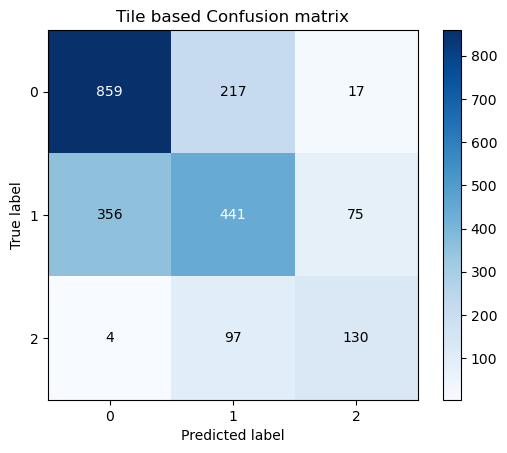

<Figure size 640x480 with 0 Axes>

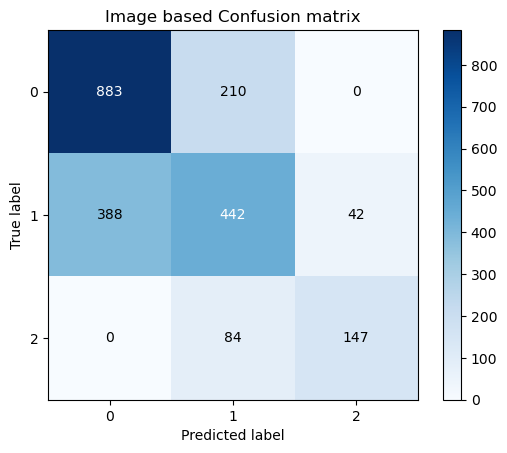

<Figure size 640x480 with 0 Axes>

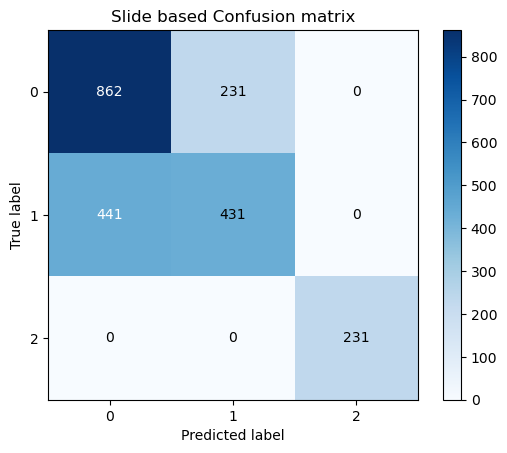

              precision    recall  f1-score   support

           0       0.70      0.79      0.74      1093
           1       0.58      0.51      0.54       872
           2       0.59      0.56      0.57       231

    accuracy                           0.65      2196
   macro avg       0.62      0.62      0.62      2196
weighted avg       0.64      0.65      0.65      2196

              precision    recall  f1-score   support

           0       0.69      0.81      0.75      1093
           1       0.60      0.51      0.55       872
           2       0.78      0.64      0.70       231

    accuracy                           0.67      2196
   macro avg       0.69      0.65      0.67      2196
weighted avg       0.67      0.67      0.66      2196

              precision    recall  f1-score   support

           0       0.66      0.79      0.72      1093
           1       0.65      0.49      0.56       872
           2       1.00      1.00      1.00       231

    accuracy        

C:\Users\salma\AppData\Local\Temp\ipykernel_20640\3894504954.py:241: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)


<Figure size 640x480 with 0 Axes>

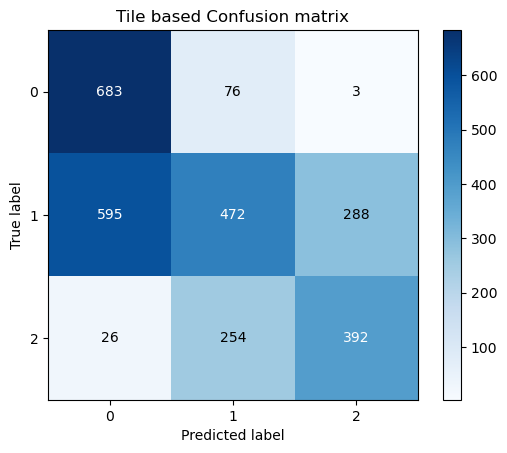

<Figure size 640x480 with 0 Axes>

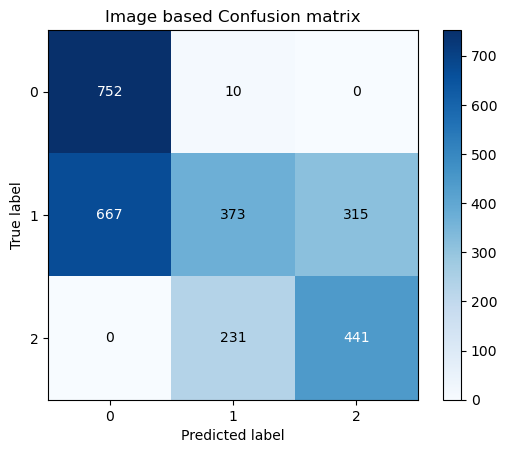

<Figure size 640x480 with 0 Axes>

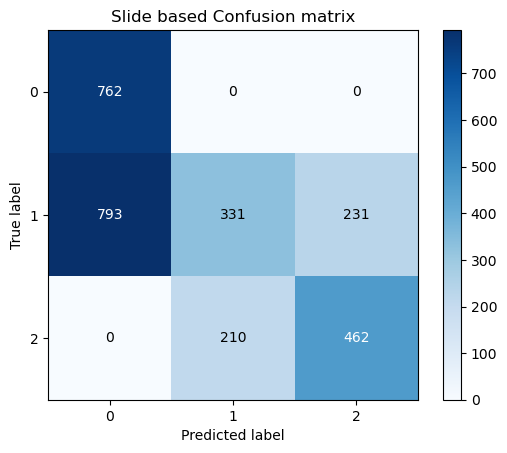

              precision    recall  f1-score   support

           0       0.52      0.90      0.66       762
           1       0.59      0.35      0.44      1355
           2       0.57      0.58      0.58       672

    accuracy                           0.55      2789
   macro avg       0.56      0.61      0.56      2789
weighted avg       0.57      0.55      0.53      2789

              precision    recall  f1-score   support

           0       0.53      0.99      0.69       762
           1       0.61      0.28      0.38      1355
           2       0.58      0.66      0.62       672

    accuracy                           0.56      2789
   macro avg       0.57      0.64      0.56      2789
weighted avg       0.58      0.56      0.52      2789

              precision    recall  f1-score   support

           0       0.49      1.00      0.66       762
           1       0.61      0.24      0.35      1355
           2       0.67      0.69      0.68       672

    accuracy        

C:\Users\salma\AppData\Local\Temp\ipykernel_20640\3894504954.py:241: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)


<Figure size 640x480 with 0 Axes>

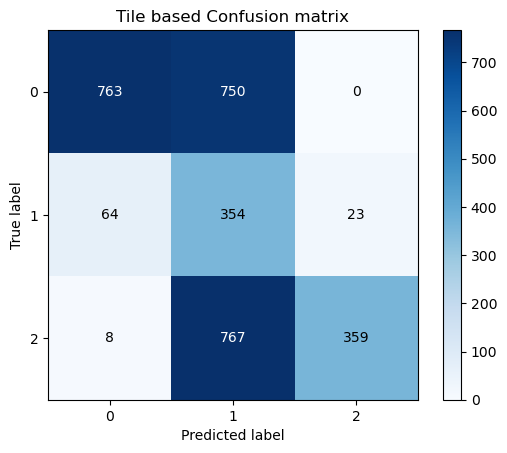

<Figure size 640x480 with 0 Axes>

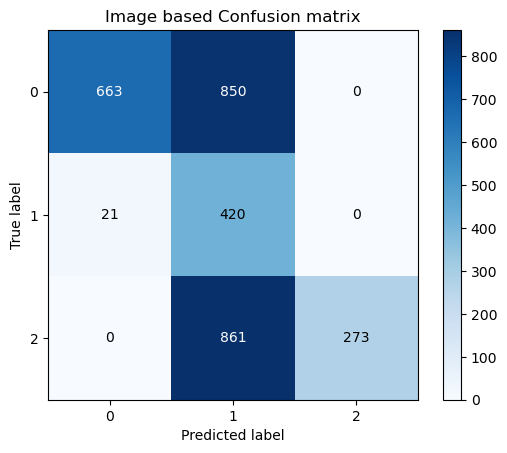

<Figure size 640x480 with 0 Axes>

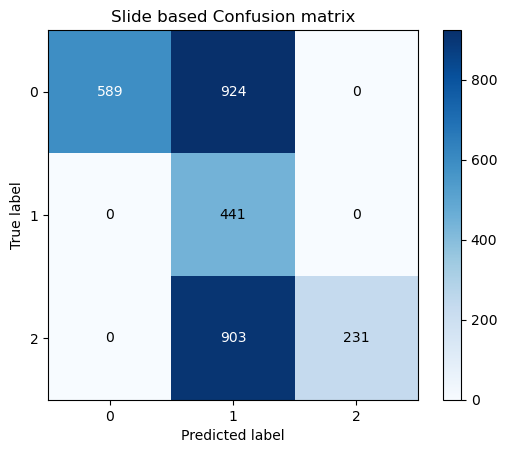

              precision    recall  f1-score   support

           0       0.91      0.50      0.65      1513
           1       0.19      0.80      0.31       441
           2       0.94      0.32      0.47      1134

    accuracy                           0.48      3088
   macro avg       0.68      0.54      0.48      3088
weighted avg       0.82      0.48      0.54      3088

              precision    recall  f1-score   support

           0       0.97      0.44      0.60      1513
           1       0.20      0.95      0.33       441
           2       1.00      0.24      0.39      1134

    accuracy                           0.44      3088
   macro avg       0.72      0.54      0.44      3088
weighted avg       0.87      0.44      0.48      3088

              precision    recall  f1-score   support

           0       1.00      0.39      0.56      1513
           1       0.19      1.00      0.33       441
           2       1.00      0.20      0.34      1134

    accuracy        

In [23]:
#n script for reading train and validation data set and train the network
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Conv2D, Flatten, Input, MaxPooling2D, Activation, BatchNormalization, Concatenate, Dropout, Add, Dense,LeakyReLU
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
import pandas as pd
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from keras.models import model_from_json
from myplot import multi_plot
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf
from tensorflow.keras.optimizers import SGD,RMSprop
from tensorflow.keras.applications import EfficientNetB0
from keras.applications.vgg16 import VGG16
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input
from keras.layers import Input, Flatten, Dense, Lambda
from keras.models import Model
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from keras.models import model_from_json
from myplot import multi_plot
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
import keras
import tensorflow as tf
from keras.callbacks import ModelCheckpoint
import pandas as pd
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.python.keras.layers import InputSpec, Layer

import pandas as pd
from sklearn.metrics import classification_report
from keras.models import Model, model_from_json

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve
#from sklearn.metrics import plot_precision_recall_curve
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
from tensorflow.keras.applications import EfficientNetB0,EfficientNetB4,EfficientNetB7
import os
##https://neptune.ai/blog/keras-metrics
from keras.callbacks import Callback
import matplotlib.pyplot as plt
import numpy as np
from scikitplot.metrics import plot_confusion_matrix, plot_roc, plot_precision_recall, plot_precision_recall_curve
######################################################################################################
class MulticlassTruePositives(tf.keras.metrics.Metric):
    def __init__(self, name='multiclass_true_positives', **kwargs):
        super(MulticlassTruePositives, self).__init__(name=name, **kwargs)
        self.true_positives = self.add_weight(name='tp', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.reshape(tf.argmax(y_pred, axis=1), shape=(-1, 1))
        values = tf.cast(y_true, 'int32') == tf.cast(y_pred, 'int32')
        values = tf.cast(values, 'float32')
        if sample_weight is not None:
            sample_weight = tf.cast(sample_weight, 'float32')
            values = tf.multiply(values, sample_weight)
        self.true_positives.assign_add(tf.reduce_sum(values))

    def result(self):
        return self.true_positives

    def reset_state(self):
        # The state of the metric will be reset at the start of each epoch.
        self.true_positives.assign(0.)

## Model definition
#################################################################################################################################
def pretrained_model_func(img_shape, num_classes,layer_type):
    inputs = tf.keras.Input(shape=(224,224,3))

    x = VGG16(
      input_tensor=inputs, 
      include_top=False,
      weights='imagenet' )

    x.trainable = False

    layer_type = 'relu'
    x = tf.keras.layers.Flatten(name='flatten')(x.output)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc1')(x)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc2')(x)
    x = tf.keras.layers.Dropout(0.5, name='dropout')(x)
    x = tf.keras.layers.Dense(3, activation='softmax', name='predictions')(x)



    METRICS = [
    keras.metrics.SparseCategoricalAccuracy(),
    MulticlassTruePositives()]



#Create your own model 
    pretrained_model = tf.keras.Model(inputs, x)
    pretrained_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=METRICS)
    return pretrained_model


#######################################################################

#validation_slide = ['ECMO','Control','ECMO+LPS','MV+LPS','MV']
validation_slide = ['1st_part','2nd_part','3rd_part']
model_name       = 'vgg_train_conv_min2_relu'
### I took the best models in terms of TP 

tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
for val_s in validation_slide:
    val_dir          = val_s # loop over all groups as validation dataset
    Sample_Slide     = {'Control' : [9, 14, 15, 16, 17, 18, 19, 20, 26, 28, 46, 47],  
                    'MV+LPS'  : [35, 36, 41, 42, 43, 44, 45],
                    'ECMO+LPS': [1, 2 ,4, 5, 6, 7, 8, 25, 37, 38, 48],
                    'MV'      : [3, 10, 13, 28, 34],
                    'ECMO'    : [11, 12, 29, 30, 31, 32, 33, 39, 40, 49]}




    validation_DATA_PATH  = val_dir+'_validation/'
    validation_LABEL_PATH = 'analysed_data/All_samples_group_1_2_3_total_score_Median/'+val_dir+'_val_total_score/validation/validation_newlabels.txt'

    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_samples = np.zeros((n_v, input_shape[0], input_shape[1], 3), dtype=np.float32)
    validation_label = np.zeros((n_v,), int)

    # Reading true labels of validation set


    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
            
   
    for i in range(n_v):
        mod_img = validation_samples[i,:, :].astype(np.float32)
        validation_samples[i, :, :, :] = mod_img
    ##After we took all validation tiles we defined the model   

    pretrained_model = pretrained_model_func(input_shape, 3,'relu') ## REGRESSION: number of classes 1 instead of 3
    weights =glob.glob('../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_2_layer_relu/'+val_dir+'*.hdf5')[0]
    print(weights)
    # Load weights, select between best_weights (val_accuracy) and final_weights from last epoch
    #pretrained_model.load_weights(weights[0])
    ###############################################################################
    
    loaded_1 = keras.models.load_model(
        weights, custom_objects={"MulticlassTruePositives": MulticlassTruePositives,'Functional':EfficientNetB4()}
    )

    print(len(pretrained_model.get_weights())) ## this is model
    weights_list = loaded_1.get_weights()      ## This is weights
    print(len(weights_list))
    #model_index  = [475,476,478]   ### from model we have more layers (not top layers)
    #weight_index = [3,4,6]         ### This is for top layers only
    #for i,w in zip(model_index,weight_index):
    #    pretrained_model.layers[i].set_weights(loaded_1.layers[w].get_weights()) ## we set the layer weight by get weights 
        #from .h5 weights 
    #pretrained_model.layers[-7].set_weights([weights_list[-8],weights_list[-7]])
    #pretrained_model.layers[-8].set_weights([weights_list[-10],weights_list[-9]])
        
    pretrained_model.layers[-1].set_weights([weights_list[-2],weights_list[-1]])
    pretrained_model.layers[-3].set_weights([weights_list[-4],weights_list[-3]])
    pretrained_model.layers[-4].set_weights([weights_list[-6],weights_list[-5]])
    pretrained_model.layers[-7].set_weights([weights_list[-8],weights_list[-7]])
    pretrained_model.layers[-8].set_weights([weights_list[-10],weights_list[-9]])
    pretrained_model.layers[-9].set_weights([weights_list[-12],weights_list[-11]])
    
    
    
    
    ###############################################################################
    # Make predictions on validation samples
    #with tf.device('/CPU:0'):
    preds = pretrained_model.predict(validation_samples)
    
    # Max predictions in numpy array
    y_pred = np.argmax(preds,axis=1)  # 0,1 or 2
    x_l = range(len(y_pred))

    ################################################################
    ### Here all predicted labels are saved in the following file
    with open(validation_LABEL_PATH,'r') as f: 
        with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','w') as fout: 
            for i,line in zip(y_pred,f):
                print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)
        fout.close()
    f.close()


    ### This is for extracting slide number from images to add
    keys = []
    Slide_dict = {}
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            S_num = str(line.split(' ')[0][6:8])
            if '.' in S_num:
                S_num = S_num.replace('.','')
            if '_' in S_num:
                S_num = S_num.replace('_','')
            if S_num not in keys:
                keys.append(S_num)
                Slide_dict[S_num]=[]

    fout.close()
    #########################################################
    ### Add all scores of tiles to the slide key
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=line.split(' ')[0][6:8]
            if '.' in key_temp:
                key_temp = key_temp.replace('.','')
            if '_' in key_temp:
                key_temp = key_temp.replace('_','')
           
            Slide_dict[key_temp].append(float(line.split(' ')[1].strip()))

    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_slide = np.ones(len(y_pred))  
    offset = 0
    for k in Slide_dict.keys():
        class_0 = [index for index, element in enumerate(Slide_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Slide_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Slide_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_slide[offset:offset+len(Slide_dict[k])]= majority_vote
        #print(y_pred_slide[offset:offset+len(Slide_dict[k])])
        offset += len(Slide_dict[k])
    ################################################################
    
    ### Add all scores of tiles to the Image name key
    keys = []
    Image_dict = {}
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            I_num = str(line.split('___')[0])
            if I_num not in keys:
                keys.append(I_num)
                Image_dict[I_num]=[]

    fout.close()
    
   
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=str(line.split('___')[0])
            Image_dict[key_temp].append(float(line.split(' ')[1].strip()))

    #print(Image_dict.keys())
    
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_image = np.ones(len(y_pred))  
    offset = 0
    for k in Image_dict.keys():
        class_0 = [index for index, element in enumerate(Image_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Image_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Image_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_image[offset:offset+len(Image_dict[k])]= majority_vote
        #print(y_pred_image[offset:offset+len(Image_dict[k])])
        offset += len(Image_dict[k])

    

    #############################
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred)
    plt.title('Tile based Confusion matrix')
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_image)
    plt.title('Image based Confusion matrix')
    
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_slide)
    plt.title('Slide based Confusion matrix')
    
    plt.show()

    



    print(classification_report(precise_scores,y_pred))
    print(classification_report(precise_scores,y_pred_image))
    print(classification_report(precise_scores,y_pred_slide))
    
    
    tile_based_scores[val_dir]  = pd.DataFrame(classification_report(precise_scores,y_pred,output_dict=True)).transpose()
    image_based_scores[val_dir] = pd.DataFrame(classification_report(precise_scores,y_pred_image,output_dict=True)).transpose()
    slide_based_scores[val_dir] = pd.DataFrame(classification_report(precise_scores,y_pred_slide,output_dict=True)).transpose()
    

df_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])

df_image = pd.concat([image_based_scores['1st_part'], image_based_scores['2nd_part'],image_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])

df_slide = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])


df_tile.to_csv('predict_result_3cv/'+model_name+'_tiles.csv')

df_image.to_csv('predict_result_3cv/'+model_name+'_image.csv')

df_slide.to_csv('predict_result_3cv/'+model_name+'_slide.csv')

dict_keys(['Slide9', 'slide14', 'slide15', 'slide16', 'Slide3', 'Slide1', 'Slide2', 'Slide4', 'Slide11', 'Slide12', 'Slide29', 'slide35', 'slide36'])


<Figure size 640x480 with 0 Axes>

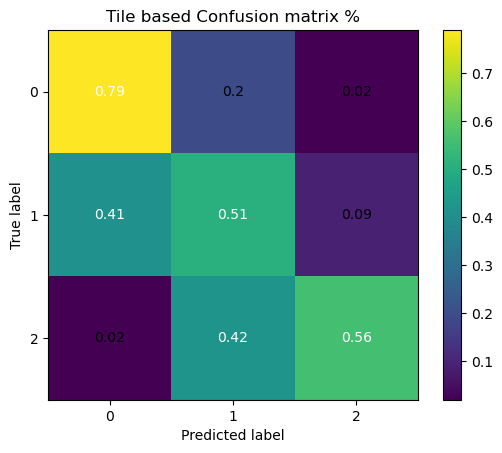

<Figure size 640x480 with 0 Axes>

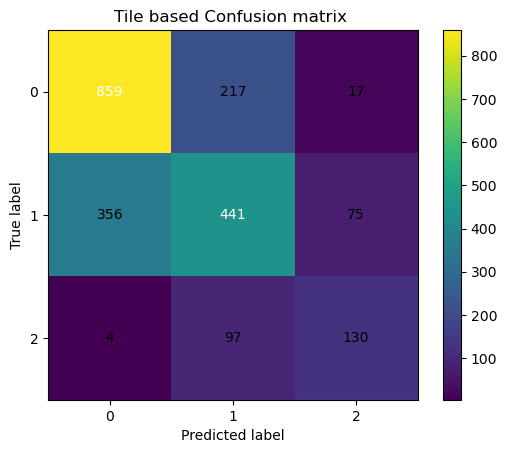

<Figure size 640x480 with 0 Axes>

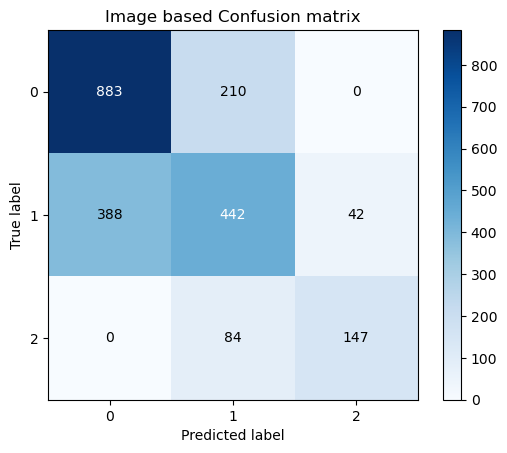

<Figure size 640x480 with 0 Axes>

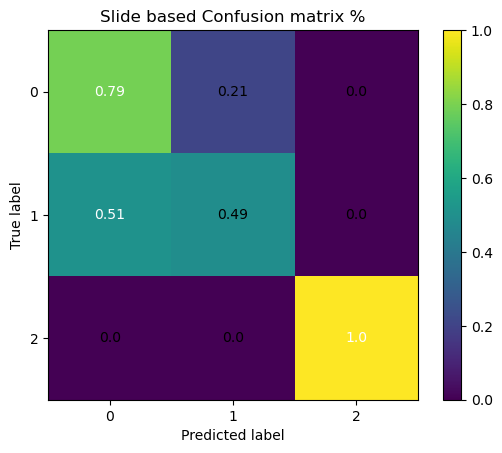

<Figure size 640x480 with 0 Axes>

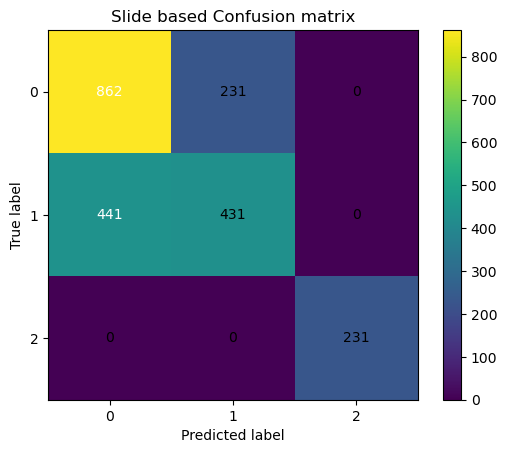

dict_keys(['slide17', 'slide18', 'slide19', 'slide20', 'Slide10', 'Slide13', 'Slide5', 'Slide6', 'Slide7', 'Slide8', 'Slide30', 'Slide31', 'Slide32', 'Slide42', 'slide41'])


<Figure size 640x480 with 0 Axes>

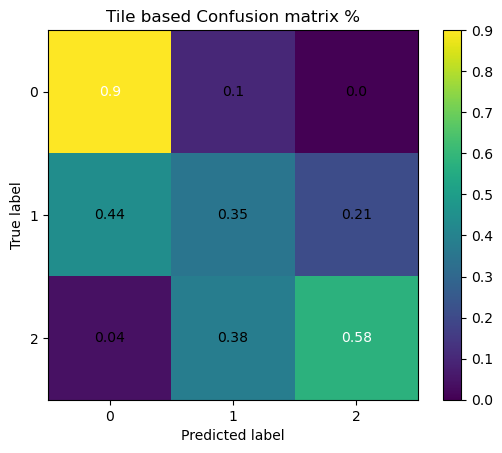

<Figure size 640x480 with 0 Axes>

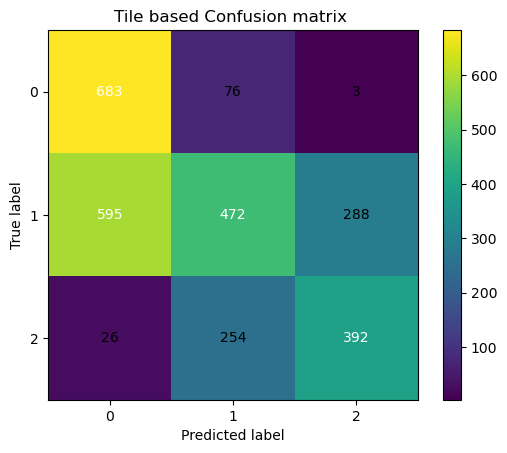

<Figure size 640x480 with 0 Axes>

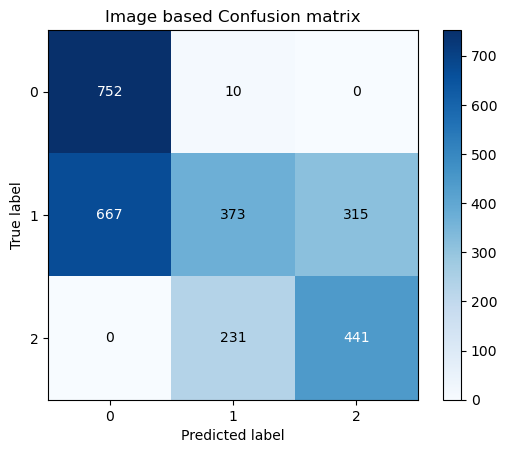

<Figure size 640x480 with 0 Axes>

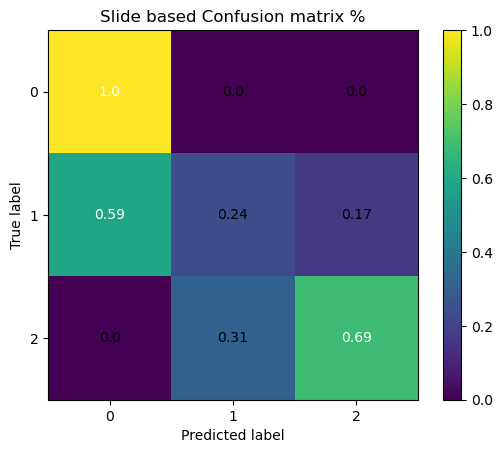

<Figure size 640x480 with 0 Axes>

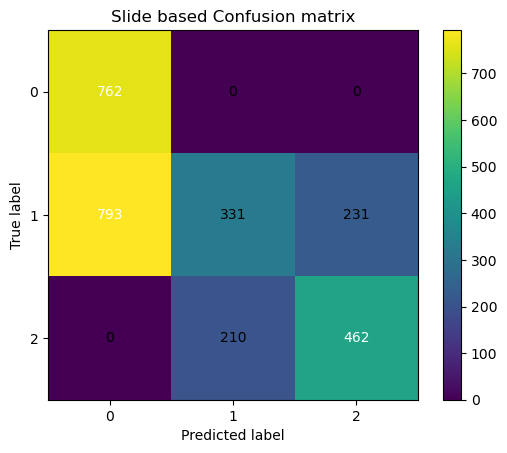

dict_keys(['slide26', 'slide28', 'slide46', 'slide47', 'Slide28', 'Slide34', 'Slide25', 'Slide37', 'Slide38', 'Slide48', 'Slide33', 'Slide39', 'Slide40', 'Slide49', 'Slide43', 'Slide45', 'slide44'])


<Figure size 640x480 with 0 Axes>

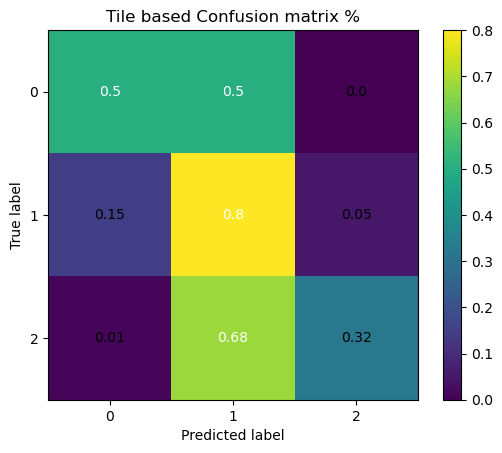

<Figure size 640x480 with 0 Axes>

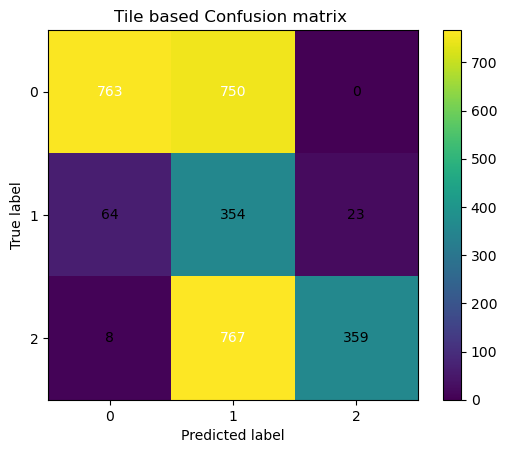

<Figure size 640x480 with 0 Axes>

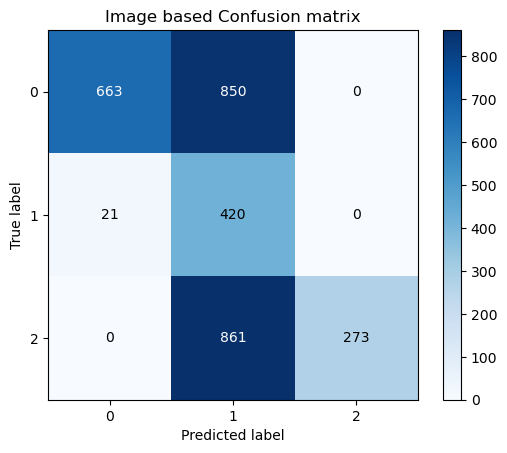

<Figure size 640x480 with 0 Axes>

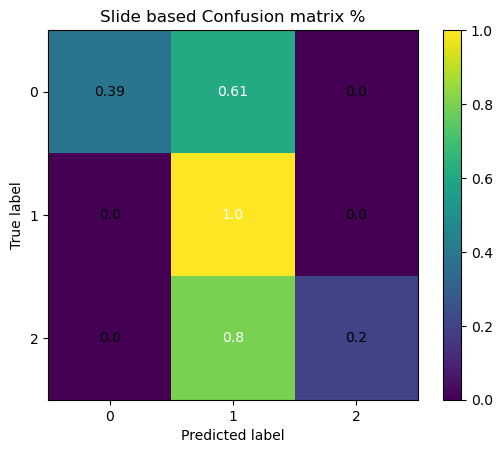

<Figure size 640x480 with 0 Axes>

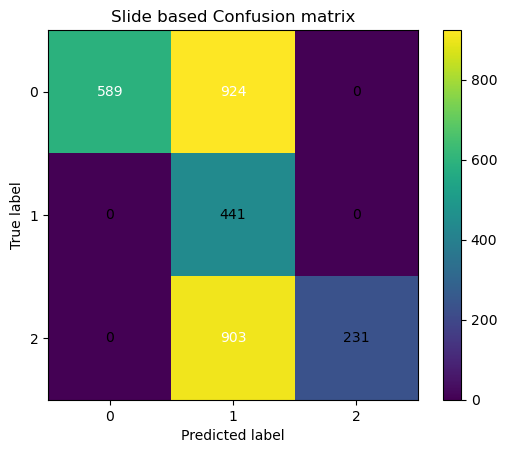

fold1                         fold2                      \
                 Precision    Recall  F1-score Precision    Recall  F1-score   
Low               0.661550  0.788655  0.719533  0.490032  1.000000  0.657747   
Medium            0.651057  0.494266  0.561930  0.611830  0.244280  0.349156   
High              1.000000  1.000000  1.000000  0.666667  0.687500  0.676923   
Micro_average     0.693989  0.693989  0.693989  0.557548  0.557548  0.557548   
weighted_average  0.692986  0.693989  0.693487  0.591766  0.557548  0.574147   

                     fold3                       Average                      
                 Precision    Recall  F1-score Precision    Recall  F1-score  
Low               1.000000  0.389293  0.560419  0.717194  0.725983  0.721562  
Medium            0.194444  1.000000  0.325581  0.485777  0.579515  0.528522  
High              1.000000  0.203704  0.338462  0.888889  0.630401  0.737656  
Micro_average     0.408355  0.408355  0.408355  0.553297  0.553297  0.553297  
weighted_average  0.884958  0.408355  0.558839  0.723236  0.553297  0.626955

In [24]:
import glob
import matplotlib.pyplot as plt
import numpy as np


from sklearn.metrics import precision_score, recall_score, f1_score,multilabel_confusion_matrix
from sklearn.metrics import precision_recall_curve
#from sklearn.metrics import plot_precision_recall_curve
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
from scikitplot.metrics import plot_confusion_matrix, plot_roc, plot_precision_recall, plot_precision_recall_curve


validation_slide = ['1st_part','2nd_part','3rd_part']
model_name       = 'vgg_train_conv_min2_relu'

tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
##Normalized thresholds
low = (10-(min_score))/(max_score-min_score)
mid = (25-(min_score))/(max_score-min_score)
for val_dir in validation_slide:
    validation_DATA_PATH  = val_dir+'_validation/'
    validation_LABEL_PATH = 'analysed_data/All_samples_group_1_2_3_total_score_Median/'+val_dir+'_val_total_score/validation/validation_newlabels.txt'

  
    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_label = np.zeros((n_v,), int)
    
    ######################################################################################################
    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            #validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
    
############################################################################################################    
    y_pred = []  
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as f:
        for line in f:
            y_pred.append(int(line.split(' ')[1].strip()))  

   ##############################################################################################    
    keys = []
    Slide_dict = {}
    flag_28  = False
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            S_num = str(line.split(' ')[0][0:8])
            if '.' in S_num:
                S_num = S_num.replace('.','')
            if '_' in S_num:
                S_num = S_num.replace('_','')
            if S_num not in keys:
                keys.append(S_num)
                Slide_dict[S_num]=[]

    fout.close()
    #########################################################
    ### Add all scores of tiles to the slide key
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=line.split(' ')[0][0:8]
            if '.' in key_temp:
                key_temp = key_temp.replace('.','')
            if '_' in key_temp:
                key_temp = key_temp.replace('_','')
           
            Slide_dict[key_temp].append(float(line.split(' ')[1].strip()))
    print(Slide_dict.keys())
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_slide = np.ones(len(y_pred))  
    offset = 0
    for k in Slide_dict.keys():
        class_0 = [index for index, element in enumerate(Slide_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Slide_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Slide_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_slide[offset:offset+len(Slide_dict[k])]= majority_vote
        #print(y_pred_slide[offset:offset+len(Slide_dict[k])])
        offset += len(Slide_dict[k])
    ################################################################
    
    ### Add all scores of tiles to the Image name key
    keys = []
    Image_dict = {}
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            I_num = str(line.split('___')[0])
            if I_num not in keys:
                keys.append(I_num)
                Image_dict[I_num]=[]

    fout.close()
    
   
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=str(line.split('___')[0])
            Image_dict[key_temp].append(float(line.split(' ')[1].strip()))

    #print(Image_dict.keys())
    
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_image = np.ones(len(y_pred))  
    offset = 0
    for k in Image_dict.keys():
        class_0 = [index for index, element in enumerate(Image_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Image_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Image_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_image[offset:offset+len(Image_dict[k])]= majority_vote
        #print(y_pred_image[offset:offset+len(Image_dict[k])])
        offset += len(Image_dict[k])

    

    #############################
    my_bins = [0, 1, 2]
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred,labels=my_bins,normalize='true', cmap='viridis')
    plt.title('Tile based Confusion matrix %')
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred,labels=my_bins, cmap='viridis')
    plt.title('Tile based Confusion matrix ')
    
    
    
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_image,labels=my_bins)
    plt.title('Image based Confusion matrix')
    
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_slide,labels=my_bins,normalize='true', cmap='viridis')
    plt.title('Slide based Confusion matrix %')
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_slide,labels=my_bins, cmap='viridis')
    plt.title('Slide based Confusion matrix')
    
    plt.show()

    
    
    

    tile_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','weighted_average'],
                                               columns=['Precision','Recall','F1-score'])
   #############################
    prec_col = np.zeros((1,5))
    tile_classes = precision_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = precision_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = precision_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    tile_weighted = precision_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = tile_classes
    prec_col[0,3] = tile_Micro
    #prec_col[0,4] = tile_Macro
    prec_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    #############################
    rec_col = np.zeros((1,5))
    tile_classes = recall_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = recall_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = recall_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    tile_weighted = recall_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    rec_col[0,0:3] = tile_classes
    rec_col[0,3] = tile_Micro
    #rec_col[0,4] = tile_Macro
    rec_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #############################
     #############################
    f1_score_col = np.zeros((1,5))
    tile_classes = f1_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = f1_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = f1_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    tile_weighted =  f1_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    f1_score_col[0,0:3] = tile_classes
    f1_score_col[0,3] = tile_Micro
    #f1_score_col[0,4] = tile_Macro
    f1_score_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
    #############################
#################################################################################################################    
       #############################

    #############################
#################################################################################################################    
    image_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','Macro_average','weighted_average'],columns=['Precision','Recall','F1-score','support'])
   #############################
    prec_col = np.zeros((1,6))
    image_classes = precision_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = precision_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = precision_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted = precision_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = image_classes
    prec_col[0,3] = image_Micro
    prec_col[0,4] = image_Macro
    prec_col[0,5] = image_weighted
    image_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    #############################
    rec_col = np.zeros((1,6))
    image_classes = recall_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = recall_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = recall_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted = recall_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    rec_col[0,0:3] = image_classes
    rec_col[0,3] = image_Micro
    rec_col[0,4] = image_Macro
    rec_col[0,5] = image_weighted
    image_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #############################
     #############################
    f1_score_col = np.zeros((1,6))
    image_classes = f1_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = f1_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = f1_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted =  f1_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    f1_score_col[0,0:3] = image_classes
    f1_score_col[0,3] = image_Micro
    f1_score_col[0,4] = image_Macro
    f1_score_col[0,5] = image_weighted
    f1_score_col = (prec_col*rec_col*2) / (prec_col+rec_col)
    image_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
    #############################
#################################################################################################################    
    supprt_col = np.zeros((1,6))
    image_class0 = np.sum(np.array(precise_scores) == 0)
    image_class1 = np.sum(np.array(precise_scores) == 1)
    image_class2 = np.sum(np.array(precise_scores) == 2)
    
    image_Micro    = len(precise_scores)
    image_Macro    = len(precise_scores)
    image_weighted = len(precise_scores)
    
    supprt_col[0,0] = image_class0
    supprt_col[0,1] = image_class1
    supprt_col[0,2] = image_class2
    
    supprt_col[0,3] = image_Micro
    supprt_col[0,4] = image_Macro
    supprt_col[0,5] = image_weighted
    image_based_scores[val_dir]['support']  =  supprt_col.transpose()
    
    
    #############################
    slide_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','weighted_average'],
                                                columns=['Precision','Recall','F1-score'])
   #############################
    prec_col = np.zeros((1,5))
    slide_classes = precision_score(precise_scores,y_pred_slide, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    slide_Micro = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='micro', zero_division='warn')
    #slide_Macro = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='macro', zero_division='warn')
    slide_weighted = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = slide_classes
    prec_col[0,3] = slide_Micro
    #prec_col[0,4] = slide_Macro
    prec_col[0,4] = slide_weighted
    slide_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    #############################
    rec_col = np.zeros((1,5))
    slide_classes = recall_score(precise_scores,y_pred_slide, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    slide_Micro = recall_score(precise_scores,y_pred_slide, sample_weight=None,average='micro', zero_division='warn')
    #slide_Macro = recall_score(precise_scores,y_pred_slide, sample_weight=None,average='macro', zero_division='warn')
    slide_weighted = recall_score(precise_scores,y_pred_slide,average='weighted', zero_division='warn')
    
    rec_col[0,0:3] = slide_classes
    rec_col[0,3] = slide_Micro
    #rec_col[0,4] = slide_Macro
    rec_col[0,4] = slide_weighted
    slide_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #############################
    f1_score_col = np.zeros((1,5))
    #slide_classes = f1_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    #slide_Micro = f1_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = f1_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    #slide_weighted =  f1_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    #f1_score_col[0,0:3] = slide_classes
    #f1_score_col[0,3] = slide_Micro
    #f1_score_col[0,4] = tile_Macro
    #f1_score_col[0,4] = slide_weighted
    f1_score_col = (prec_col*rec_col*2) / (prec_col+rec_col)
    slide_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
     #############################
        #############################
#################################################################################################################    
 ################################################################################################
df_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part']], axis=1,
                     keys=['fold1','fold2','fold3'])

df_img  = pd.concat([image_based_scores['1st_part'], image_based_scores['2nd_part'],image_based_scores['3rd_part']], axis=1,
                     keys=['fold1','fold2','fold3'])

df_slide  = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part']], axis=1,
                       keys=['fold1','fold2','fold3'])

#################################################################################################

df_1_tile = np.array(df_tile.iloc[0:6,0:3]).astype(float)
df_2_tile = np.array(df_tile.iloc[0:6,3:6]).astype(float)
df_3_tile = np.array(df_tile.iloc[0:6,6:9]).astype(float)





a = [df_1_tile,df_2_tile,df_3_tile]



tile_mean = np.mean(a,axis=0)


tile_m = pd.DataFrame(tile_mean,columns= ['Precision','Recall','F1-score'],index = ['Low','Medium','High','Micro_average','weighted_average'])
tile_m


tile_m['F1-score'] = (2*tile_m['Precision']*tile_m['Recall'])/(tile_m['Precision']+tile_m['Recall'])

tile_m
############################################################################################


df_1_img = np.array(df_img.iloc[0:7,0:3]).astype(float)
df_2_img = np.array(df_img.iloc[0:7,4:7]).astype(float)
df_3_img = np.array(df_img.iloc[0:7,8:11]).astype(float)


weights_1 = np.array(df_img.iloc[0:7,3]).astype(float)*np.identity(6)
weights_2 = np.array(df_img.iloc[0:7,7]).astype(float)*np.identity(6)
weights_3 = np.array(df_img.iloc[0:7,11]).astype(float)*np.identity(6)

sum_weights = np.matmul((weights_1+weights_2+weights_3),np.ones([6,1]))



b = [np.matmul(weights_1/sum_weights,df_1_img),np.matmul(weights_2/sum_weights,df_2_img),
    np.matmul(weights_3/sum_weights,df_3_img)]


img_mean = np.sum(b,axis=0)
img_m = pd.DataFrame(img_mean,columns= ['precision','recall','f1-score'],index = ['Low','Medium','High','Micro_average','Macro_average','weighted_average'])
img_m

###################################################################################################

#df_1_slide = np.array(df_slide.iloc[0:6,0:2]).astype(float)
#df_2_slide = np.array(df_slide.iloc[0:6,2:4]).astype(float)
#df_3_slide = np.array(df_slide.iloc[0:6,4:6]).astype(float)

df_1_slide = np.array(df_slide.iloc[0:6,0:3]).astype(float)
df_2_slide = np.array(df_slide.iloc[0:6,3:6]).astype(float)
df_3_slide = np.array(df_slide.iloc[0:6,6:9]).astype(float)





a = [df_1_slide,df_2_slide,df_3_slide]



slide_mean = np.mean(a,axis=0)
slide_m = pd.DataFrame(slide_mean,columns= ['Precision','Recall','F1-score'],
                       index = ['Low','Medium','High','Micro_average','weighted_average'])

slide_m['F1-score'] = (2*slide_m['Precision']*slide_m['Recall'])/(slide_m['Precision']+slide_m['Recall'])


#df_vgg_man_aug_tile = pd.concat([df_tile['fold1'],df_tile['fold2'],df_tile['fold3'],tile_m],axis=1,keys=['fold1,fold2,fold3','Average'])
#df_vgg_man_aug_tile
df_vgg_train_conv_min2_relu_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part'],tile_m], axis=1,keys=['fold1','fold2','fold3','Average'])
df_vgg_train_conv_min2_relu_tile

df_vgg_train_conv_min2_relu_slide  = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part'],slide_m], axis=1,keys=['fold1','fold2','fold3','Average'])
df_vgg_train_conv_min2_relu_slide



### Next cell VGG16 + layer (-2)(conv) + leakyRelU

../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_2_layer_LeakyReLU\1st_part_best_weights.22-1.88.hdf5
32
32


C:\Users\salma\AppData\Local\Temp\ipykernel_20640\1419865014.py:241: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)


<Figure size 640x480 with 0 Axes>

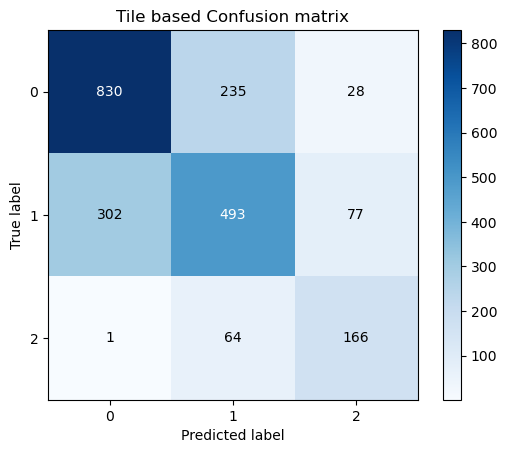

<Figure size 640x480 with 0 Axes>

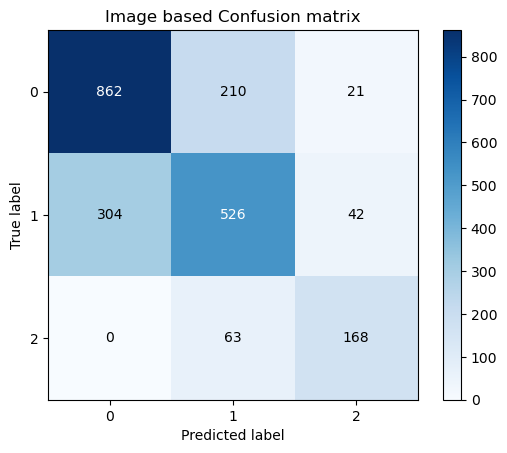

<Figure size 640x480 with 0 Axes>

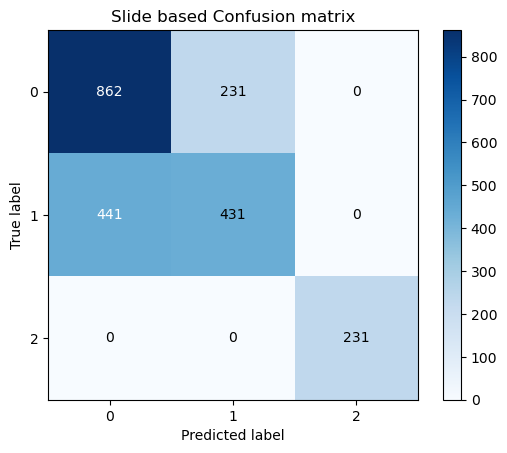

              precision    recall  f1-score   support

           0       0.73      0.76      0.75      1093
           1       0.62      0.57      0.59       872
           2       0.61      0.72      0.66       231

    accuracy                           0.68      2196
   macro avg       0.66      0.68      0.67      2196
weighted avg       0.68      0.68      0.68      2196

              precision    recall  f1-score   support

           0       0.74      0.79      0.76      1093
           1       0.66      0.60      0.63       872
           2       0.73      0.73      0.73       231

    accuracy                           0.71      2196
   macro avg       0.71      0.71      0.71      2196
weighted avg       0.71      0.71      0.71      2196

              precision    recall  f1-score   support

           0       0.66      0.79      0.72      1093
           1       0.65      0.49      0.56       872
           2       1.00      1.00      1.00       231

    accuracy        

C:\Users\salma\AppData\Local\Temp\ipykernel_20640\1419865014.py:241: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)


<Figure size 640x480 with 0 Axes>

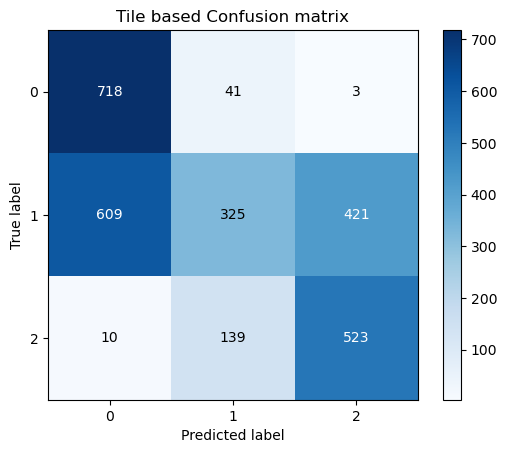

<Figure size 640x480 with 0 Axes>

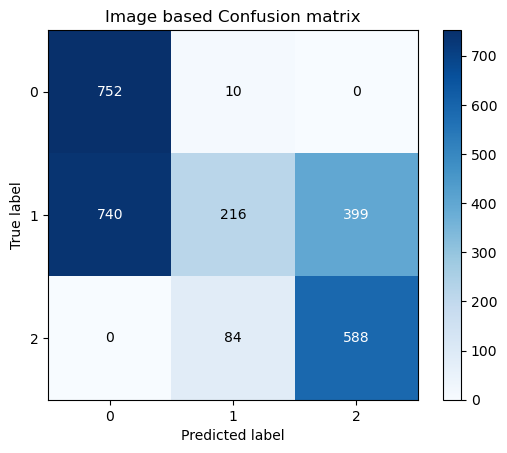

<Figure size 640x480 with 0 Axes>

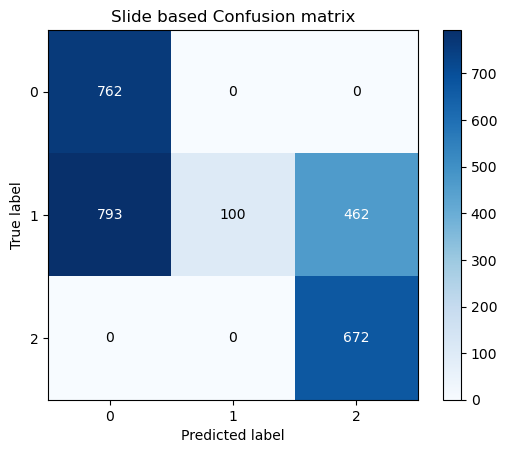

              precision    recall  f1-score   support

           0       0.54      0.94      0.68       762
           1       0.64      0.24      0.35      1355
           2       0.55      0.78      0.65       672

    accuracy                           0.56      2789
   macro avg       0.58      0.65      0.56      2789
weighted avg       0.59      0.56      0.51      2789

              precision    recall  f1-score   support

           0       0.50      0.99      0.67       762
           1       0.70      0.16      0.26      1355
           2       0.60      0.88      0.71       672

    accuracy                           0.56      2789
   macro avg       0.60      0.67      0.55      2789
weighted avg       0.62      0.56      0.48      2789

              precision    recall  f1-score   support

           0       0.49      1.00      0.66       762
           1       1.00      0.07      0.14      1355
           2       0.59      1.00      0.74       672

    accuracy        

C:\Users\salma\AppData\Local\Temp\ipykernel_20640\1419865014.py:241: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)


<Figure size 640x480 with 0 Axes>

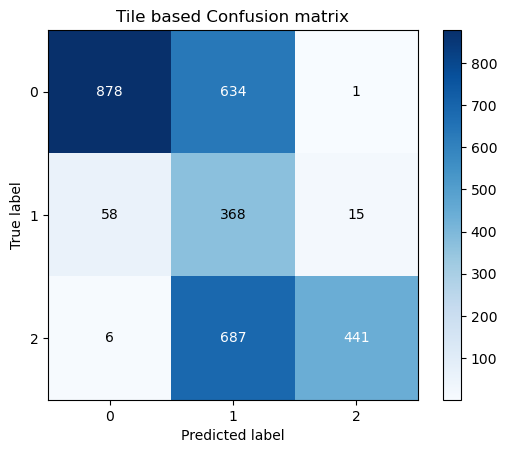

<Figure size 640x480 with 0 Axes>

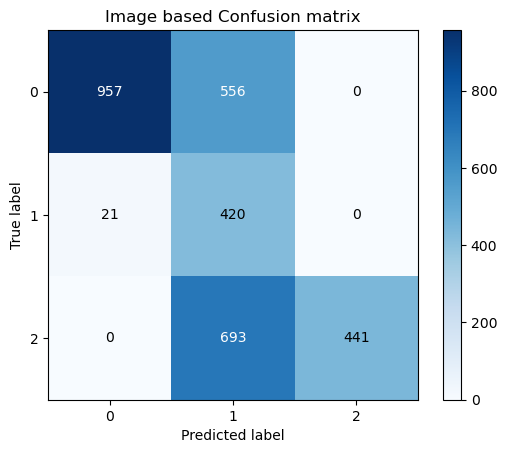

<Figure size 640x480 with 0 Axes>

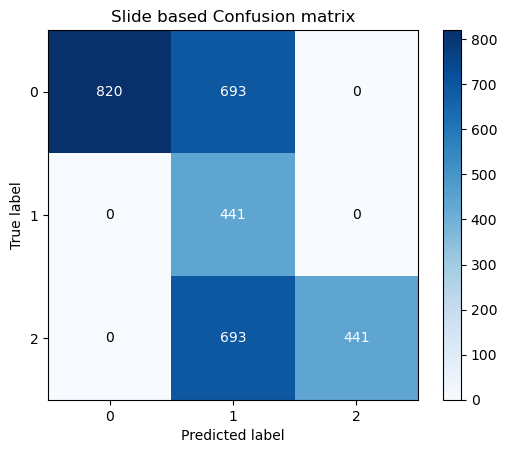

              precision    recall  f1-score   support

           0       0.93      0.58      0.72      1513
           1       0.22      0.83      0.35       441
           2       0.96      0.39      0.55      1134

    accuracy                           0.55      3088
   macro avg       0.70      0.60      0.54      3088
weighted avg       0.84      0.55      0.60      3088

              precision    recall  f1-score   support

           0       0.98      0.63      0.77      1513
           1       0.25      0.95      0.40       441
           2       1.00      0.39      0.56      1134

    accuracy                           0.59      3088
   macro avg       0.74      0.66      0.58      3088
weighted avg       0.88      0.59      0.64      3088

              precision    recall  f1-score   support

           0       1.00      0.54      0.70      1513
           1       0.24      1.00      0.39       441
           2       1.00      0.39      0.56      1134

    accuracy        

In [25]:
#n script for reading train and validation data set and train the network
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Conv2D, Flatten, Input, MaxPooling2D, Activation, BatchNormalization, Concatenate, Dropout, Add, Dense,LeakyReLU
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
import pandas as pd
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from keras.models import model_from_json
from myplot import multi_plot
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf
from tensorflow.keras.optimizers import SGD,RMSprop
from tensorflow.keras.applications import EfficientNetB0
from keras.applications.vgg16 import VGG16
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input
from keras.layers import Input, Flatten, Dense, Lambda
from keras.models import Model
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from keras.models import model_from_json
from myplot import multi_plot
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
import keras
import tensorflow as tf
from keras.callbacks import ModelCheckpoint
import pandas as pd
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.python.keras.layers import InputSpec, Layer

import pandas as pd
from sklearn.metrics import classification_report
from keras.models import Model, model_from_json

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve
#from sklearn.metrics import plot_precision_recall_curve
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
from tensorflow.keras.applications import EfficientNetB0,EfficientNetB4,EfficientNetB7
import os
##https://neptune.ai/blog/keras-metrics
from keras.callbacks import Callback
import matplotlib.pyplot as plt
import numpy as np
from scikitplot.metrics import plot_confusion_matrix, plot_roc, plot_precision_recall, plot_precision_recall_curve
######################################################################################################
class MulticlassTruePositives(tf.keras.metrics.Metric):
    def __init__(self, name='multiclass_true_positives', **kwargs):
        super(MulticlassTruePositives, self).__init__(name=name, **kwargs)
        self.true_positives = self.add_weight(name='tp', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.reshape(tf.argmax(y_pred, axis=1), shape=(-1, 1))
        values = tf.cast(y_true, 'int32') == tf.cast(y_pred, 'int32')
        values = tf.cast(values, 'float32')
        if sample_weight is not None:
            sample_weight = tf.cast(sample_weight, 'float32')
            values = tf.multiply(values, sample_weight)
        self.true_positives.assign_add(tf.reduce_sum(values))

    def result(self):
        return self.true_positives

    def reset_state(self):
        # The state of the metric will be reset at the start of each epoch.
        self.true_positives.assign(0.)

## Model definition
#################################################################################################################################
def pretrained_model_func(img_shape, num_classes,layer_type):
    inputs = tf.keras.Input(shape=(224,224,3))

    x = VGG16(
      input_tensor=inputs, 
      include_top=False,
      weights='imagenet' )

    x.trainable = False

    layer_type = LeakyReLU(0.2)#'relu'
    x = tf.keras.layers.Flatten(name='flatten')(x.output)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc1')(x)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc2')(x)
    x = tf.keras.layers.Dropout(0.5, name='dropout')(x)
    x = tf.keras.layers.Dense(3, activation='softmax', name='predictions')(x)



    METRICS = [
    keras.metrics.SparseCategoricalAccuracy(),
    MulticlassTruePositives()]



#Create your own model 
    pretrained_model = tf.keras.Model(inputs, x)
    pretrained_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=METRICS)
    return pretrained_model


#######################################################################

#validation_slide = ['ECMO','Control','ECMO+LPS','MV+LPS','MV']
validation_slide = ['1st_part','2nd_part','3rd_part']
model_name       = 'vgg_train_conv_min2_Leakyrelu'
### I took the best models in terms of TP 

tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
for val_s in validation_slide:
    val_dir          = val_s # loop over all groups as validation dataset
    Sample_Slide     = {'Control' : [9, 14, 15, 16, 17, 18, 19, 20, 26, 28, 46, 47],  
                    'MV+LPS'  : [35, 36, 41, 42, 43, 44, 45],
                    'ECMO+LPS': [1, 2 ,4, 5, 6, 7, 8, 25, 37, 38, 48],
                    'MV'      : [3, 10, 13, 28, 34],
                    'ECMO'    : [11, 12, 29, 30, 31, 32, 33, 39, 40, 49]}




    validation_DATA_PATH  = val_dir+'_validation/'
    validation_LABEL_PATH = 'analysed_data/All_samples_group_1_2_3_total_score_Median/'+val_dir+'_val_total_score/validation/validation_newlabels.txt'

    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_samples = np.zeros((n_v, input_shape[0], input_shape[1], 3), dtype=np.float32)
    validation_label = np.zeros((n_v,), int)

    # Reading true labels of validation set


    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
            
   
    for i in range(n_v):
        mod_img = validation_samples[i,:, :].astype(np.float32)
        validation_samples[i, :, :, :] = mod_img
    ##After we took all validation tiles we defined the model   

    pretrained_model = pretrained_model_func(input_shape, 3,LeakyReLU(0.2)) ## REGRESSION: number of classes 1 instead of 3
    weights =glob.glob('../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_2_layer_LeakyReLU/'+val_dir+'*.hdf5')[0]
    print(weights)
    # Load weights, select between best_weights (val_accuracy) and final_weights from last epoch
    #pretrained_model.load_weights(weights[0])
    ###############################################################################
    
    loaded_1 = keras.models.load_model(
        weights, custom_objects={"MulticlassTruePositives": MulticlassTruePositives,'Functional':EfficientNetB4()}
    )

    print(len(pretrained_model.get_weights())) ## this is model
    weights_list = loaded_1.get_weights()      ## This is weights
    print(len(weights_list))
    #model_index  = [475,476,478]   ### from model we have more layers (not top layers)
    #weight_index = [3,4,6]         ### This is for top layers only
    #for i,w in zip(model_index,weight_index):
    #    pretrained_model.layers[i].set_weights(loaded_1.layers[w].get_weights()) ## we set the layer weight by get weights 
        #from .h5 weights 
    #pretrained_model.layers[-7].set_weights([weights_list[-8],weights_list[-7]])
    #pretrained_model.layers[-8].set_weights([weights_list[-10],weights_list[-9]])
        
    pretrained_model.layers[-1].set_weights([weights_list[-2],weights_list[-1]])
    pretrained_model.layers[-3].set_weights([weights_list[-4],weights_list[-3]])
    pretrained_model.layers[-4].set_weights([weights_list[-6],weights_list[-5]])
    pretrained_model.layers[-7].set_weights([weights_list[-8],weights_list[-7]])
    pretrained_model.layers[-8].set_weights([weights_list[-10],weights_list[-9]])
    pretrained_model.layers[-9].set_weights([weights_list[-12],weights_list[-11]])
    
    
    
    
    ###############################################################################
    # Make predictions on validation samples
    #with tf.device('/CPU:0'):
    preds = pretrained_model.predict(validation_samples)
    
    # Max predictions in numpy array
    y_pred = np.argmax(preds,axis=1)  # 0,1 or 2
    x_l = range(len(y_pred))

    ################################################################
    ### Here all predicted labels are saved in the following file
    with open(validation_LABEL_PATH,'r') as f: 
        with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','w') as fout: 
            for i,line in zip(y_pred,f):
                print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)
        fout.close()
    f.close()


    ### This is for extracting slide number from images to add
    keys = []
    Slide_dict = {}
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            S_num = str(line.split(' ')[0][6:8])
            if '.' in S_num:
                S_num = S_num.replace('.','')
            if '_' in S_num:
                S_num = S_num.replace('_','')
            if S_num not in keys:
                keys.append(S_num)
                Slide_dict[S_num]=[]

    fout.close()
    #########################################################
    ### Add all scores of tiles to the slide key
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=line.split(' ')[0][6:8]
            if '.' in key_temp:
                key_temp = key_temp.replace('.','')
            if '_' in key_temp:
                key_temp = key_temp.replace('_','')
           
            Slide_dict[key_temp].append(float(line.split(' ')[1].strip()))

    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_slide = np.ones(len(y_pred))  
    offset = 0
    for k in Slide_dict.keys():
        class_0 = [index for index, element in enumerate(Slide_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Slide_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Slide_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_slide[offset:offset+len(Slide_dict[k])]= majority_vote
        #print(y_pred_slide[offset:offset+len(Slide_dict[k])])
        offset += len(Slide_dict[k])
    ################################################################
    
    ### Add all scores of tiles to the Image name key
    keys = []
    Image_dict = {}
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            I_num = str(line.split('___')[0])
            if I_num not in keys:
                keys.append(I_num)
                Image_dict[I_num]=[]

    fout.close()
    
   
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=str(line.split('___')[0])
            Image_dict[key_temp].append(float(line.split(' ')[1].strip()))

    #print(Image_dict.keys())
    
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_image = np.ones(len(y_pred))  
    offset = 0
    for k in Image_dict.keys():
        class_0 = [index for index, element in enumerate(Image_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Image_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Image_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_image[offset:offset+len(Image_dict[k])]= majority_vote
        #print(y_pred_image[offset:offset+len(Image_dict[k])])
        offset += len(Image_dict[k])

    

    #############################
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred)
    plt.title('Tile based Confusion matrix')
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_image)
    plt.title('Image based Confusion matrix')
    
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_slide)
    plt.title('Slide based Confusion matrix')
    
    plt.show()

    



    print(classification_report(precise_scores,y_pred))
    print(classification_report(precise_scores,y_pred_image))
    print(classification_report(precise_scores,y_pred_slide))
    
    
    tile_based_scores[val_dir]  = pd.DataFrame(classification_report(precise_scores,y_pred,output_dict=True)).transpose()
    image_based_scores[val_dir] = pd.DataFrame(classification_report(precise_scores,y_pred_image,output_dict=True)).transpose()
    slide_based_scores[val_dir] = pd.DataFrame(classification_report(precise_scores,y_pred_slide,output_dict=True)).transpose()
    

df_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])

df_image = pd.concat([image_based_scores['1st_part'], image_based_scores['2nd_part'],image_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])

df_slide = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])


df_tile.to_csv('predict_result_3cv/'+model_name+'_tiles.csv')

df_image.to_csv('predict_result_3cv/'+model_name+'_image.csv')

df_slide.to_csv('predict_result_3cv/'+model_name+'_slide.csv')

dict_keys(['Slide9', 'slide14', 'slide15', 'slide16', 'Slide3', 'Slide1', 'Slide2', 'Slide4', 'Slide11', 'Slide12', 'Slide29', 'slide35', 'slide36'])


<Figure size 640x480 with 0 Axes>

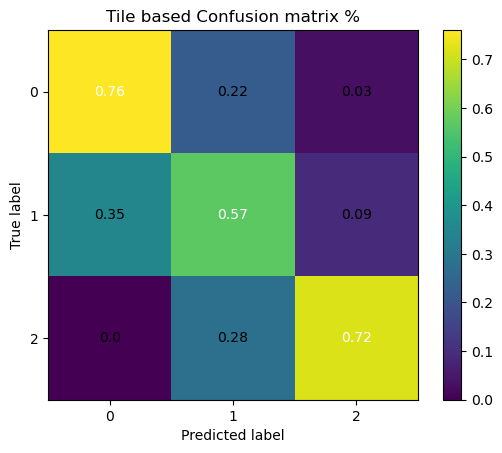

<Figure size 640x480 with 0 Axes>

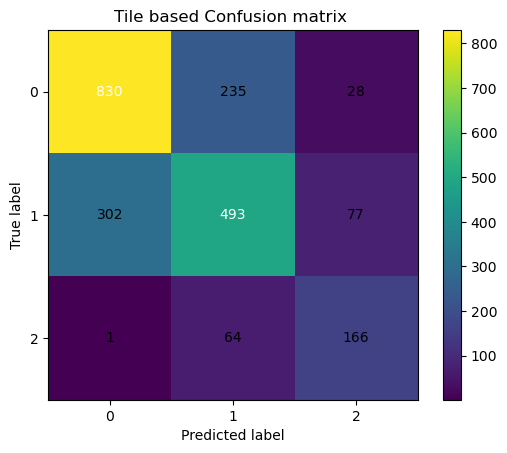

<Figure size 640x480 with 0 Axes>

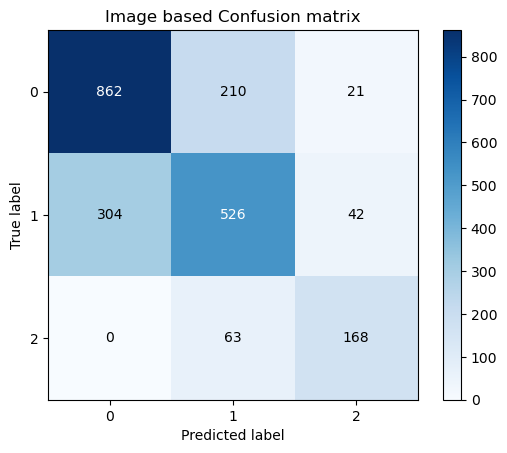

<Figure size 640x480 with 0 Axes>

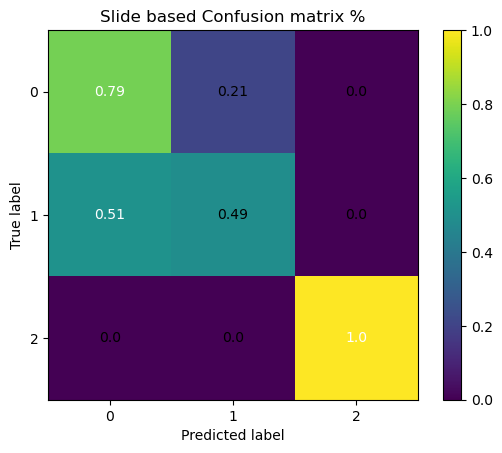

<Figure size 640x480 with 0 Axes>

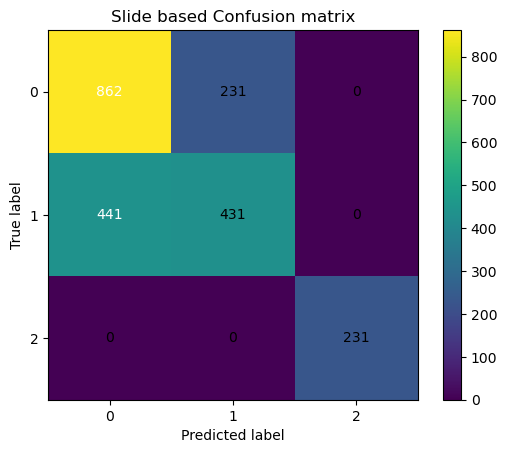

dict_keys(['slide17', 'slide18', 'slide19', 'slide20', 'Slide10', 'Slide13', 'Slide5', 'Slide6', 'Slide7', 'Slide8', 'Slide30', 'Slide31', 'Slide32', 'Slide42', 'slide41'])


<Figure size 640x480 with 0 Axes>

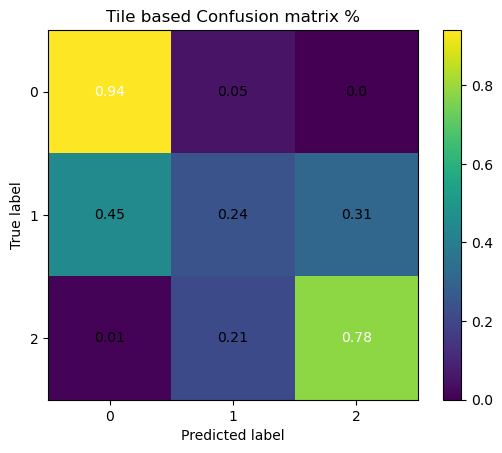

<Figure size 640x480 with 0 Axes>

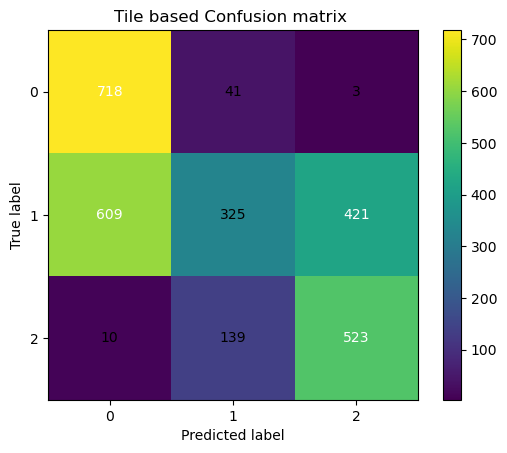

<Figure size 640x480 with 0 Axes>

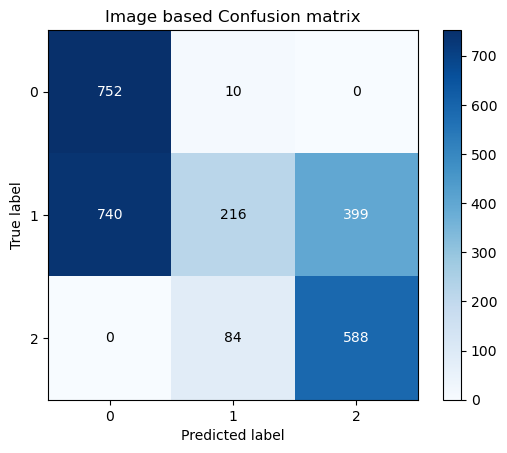

<Figure size 640x480 with 0 Axes>

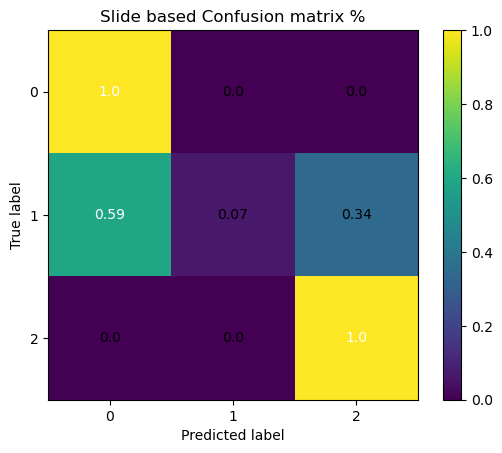

<Figure size 640x480 with 0 Axes>

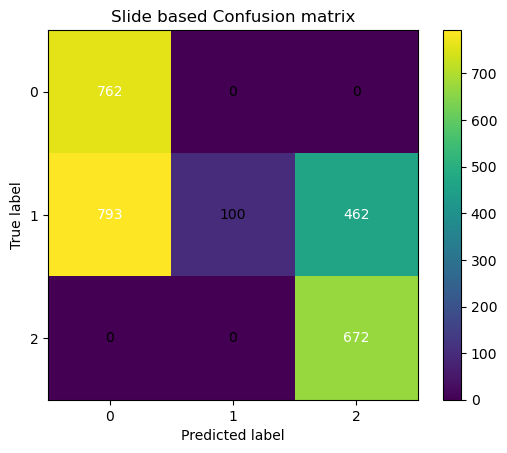

dict_keys(['slide26', 'slide28', 'slide46', 'slide47', 'Slide28', 'Slide34', 'Slide25', 'Slide37', 'Slide38', 'Slide48', 'Slide33', 'Slide39', 'Slide40', 'Slide49', 'Slide43', 'Slide45', 'slide44'])


<Figure size 640x480 with 0 Axes>

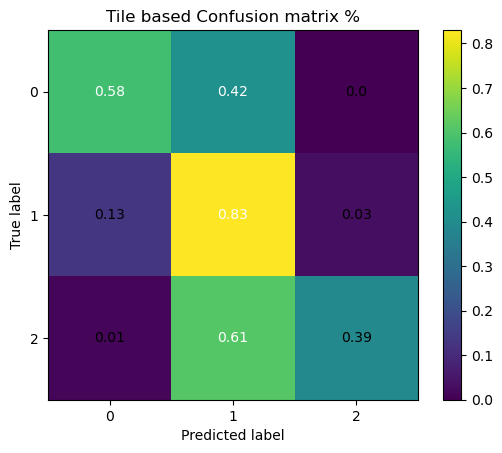

<Figure size 640x480 with 0 Axes>

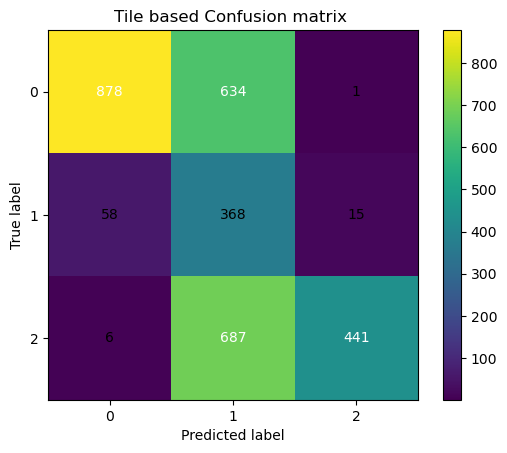

<Figure size 640x480 with 0 Axes>

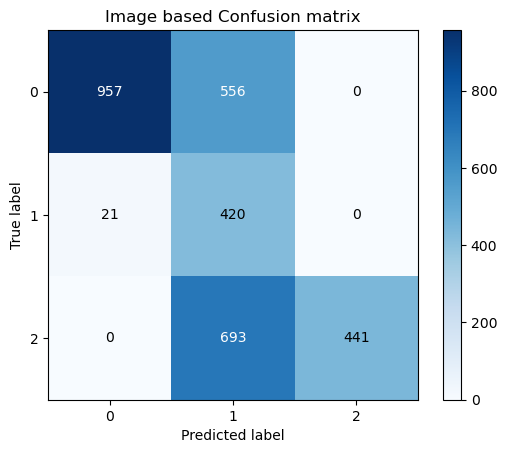

<Figure size 640x480 with 0 Axes>

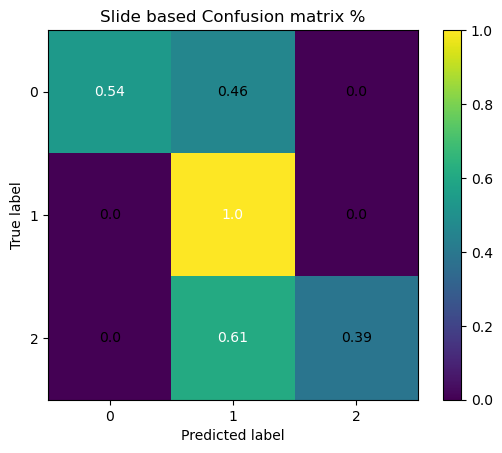

<Figure size 640x480 with 0 Axes>

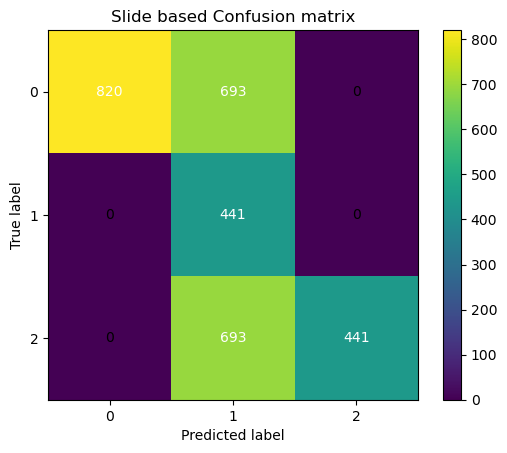

fold1                         fold2                      \
                 Precision    Recall  F1-score Precision    Recall  F1-score   
Low               0.661550  0.788655  0.719533  0.490032  1.000000  0.657747   
Medium            0.651057  0.494266  0.561930  1.000000  0.073801  0.137457   
High              1.000000  1.000000  1.000000  0.592593  1.000000  0.744186   
Micro_average     0.693989  0.693989  0.693989  0.550018  0.550018  0.550018   
weighted_average  0.692986  0.693989  0.693487  0.762505  0.550018  0.639062   

                     fold3                       Average                      
                 Precision    Recall  F1-score Precision    Recall  F1-score  
Low               1.000000  0.541970  0.702958  0.717194  0.776875  0.745843  
Medium            0.241379  1.000000  0.388889  0.630812  0.522689  0.571683  
High              1.000000  0.388889  0.560000  0.864198  0.796296  0.828859  
Micro_average     0.551166  0.551166  0.551166  0.598391  0.598391  0.598391  
weighted_average  0.891661  0.551166  0.681236  0.782384  0.598391  0.678129

In [26]:
import glob
import matplotlib.pyplot as plt
import numpy as np


from sklearn.metrics import precision_score, recall_score, f1_score,multilabel_confusion_matrix
from sklearn.metrics import precision_recall_curve
#from sklearn.metrics import plot_precision_recall_curve
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
from scikitplot.metrics import plot_confusion_matrix, plot_roc, plot_precision_recall, plot_precision_recall_curve


validation_slide = ['1st_part','2nd_part','3rd_part']
model_name       = 'vgg_train_conv_min2_Leakyrelu'

tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
##Normalized thresholds
low = (10-(min_score))/(max_score-min_score)
mid = (25-(min_score))/(max_score-min_score)
for val_dir in validation_slide:
    validation_DATA_PATH  = val_dir+'_validation/'
    validation_LABEL_PATH = 'analysed_data/All_samples_group_1_2_3_total_score_Median/'+val_dir+'_val_total_score/validation/validation_newlabels.txt'

  
    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_label = np.zeros((n_v,), int)
    
    ######################################################################################################
    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            #validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
    
############################################################################################################    
    y_pred = []  
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as f:
        for line in f:
            y_pred.append(int(line.split(' ')[1].strip()))  

   ##############################################################################################    
    keys = []
    Slide_dict = {}
    flag_28  = False
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            S_num = str(line.split(' ')[0][0:8])
            if '.' in S_num:
                S_num = S_num.replace('.','')
            if '_' in S_num:
                S_num = S_num.replace('_','')
            if S_num not in keys:
                keys.append(S_num)
                Slide_dict[S_num]=[]

    fout.close()
    #########################################################
    ### Add all scores of tiles to the slide key
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=line.split(' ')[0][0:8]
            if '.' in key_temp:
                key_temp = key_temp.replace('.','')
            if '_' in key_temp:
                key_temp = key_temp.replace('_','')
           
            Slide_dict[key_temp].append(float(line.split(' ')[1].strip()))
    print(Slide_dict.keys())
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_slide = np.ones(len(y_pred))  
    offset = 0
    for k in Slide_dict.keys():
        class_0 = [index for index, element in enumerate(Slide_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Slide_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Slide_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_slide[offset:offset+len(Slide_dict[k])]= majority_vote
        #print(y_pred_slide[offset:offset+len(Slide_dict[k])])
        offset += len(Slide_dict[k])
    ################################################################
    
    ### Add all scores of tiles to the Image name key
    keys = []
    Image_dict = {}
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            I_num = str(line.split('___')[0])
            if I_num not in keys:
                keys.append(I_num)
                Image_dict[I_num]=[]

    fout.close()
    
   
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=str(line.split('___')[0])
            Image_dict[key_temp].append(float(line.split(' ')[1].strip()))

    #print(Image_dict.keys())
    
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_image = np.ones(len(y_pred))  
    offset = 0
    for k in Image_dict.keys():
        class_0 = [index for index, element in enumerate(Image_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Image_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Image_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_image[offset:offset+len(Image_dict[k])]= majority_vote
        #print(y_pred_image[offset:offset+len(Image_dict[k])])
        offset += len(Image_dict[k])

    

    #############################
    my_bins = [0, 1, 2]
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred,labels=my_bins,normalize='true', cmap='viridis')
    plt.title('Tile based Confusion matrix %')
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred,labels=my_bins, cmap='viridis')
    plt.title('Tile based Confusion matrix ')
    
    
    
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_image,labels=my_bins)
    plt.title('Image based Confusion matrix')
    
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_slide,labels=my_bins,normalize='true', cmap='viridis')
    plt.title('Slide based Confusion matrix %')
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_slide,labels=my_bins, cmap='viridis')
    plt.title('Slide based Confusion matrix')
    
    plt.show()

    
    
    

    tile_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','weighted_average'],
                                               columns=['Precision','Recall','F1-score'])
   #############################
    prec_col = np.zeros((1,5))
    tile_classes = precision_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = precision_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = precision_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    tile_weighted = precision_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = tile_classes
    prec_col[0,3] = tile_Micro
    #prec_col[0,4] = tile_Macro
    prec_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    #############################
    rec_col = np.zeros((1,5))
    tile_classes = recall_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = recall_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = recall_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    tile_weighted = recall_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    rec_col[0,0:3] = tile_classes
    rec_col[0,3] = tile_Micro
    #rec_col[0,4] = tile_Macro
    rec_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #############################
     #############################
    f1_score_col = np.zeros((1,5))
    tile_classes = f1_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = f1_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = f1_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    tile_weighted =  f1_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    f1_score_col[0,0:3] = tile_classes
    f1_score_col[0,3] = tile_Micro
    #f1_score_col[0,4] = tile_Macro
    f1_score_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
    #############################
#################################################################################################################    
       #############################

    #############################
#################################################################################################################    
    image_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','Macro_average','weighted_average'],columns=['Precision','Recall','F1-score','support'])
   #############################
    prec_col = np.zeros((1,6))
    image_classes = precision_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = precision_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = precision_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted = precision_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = image_classes
    prec_col[0,3] = image_Micro
    prec_col[0,4] = image_Macro
    prec_col[0,5] = image_weighted
    image_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    #############################
    rec_col = np.zeros((1,6))
    image_classes = recall_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = recall_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = recall_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted = recall_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    rec_col[0,0:3] = image_classes
    rec_col[0,3] = image_Micro
    rec_col[0,4] = image_Macro
    rec_col[0,5] = image_weighted
    image_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #############################
     #############################
    f1_score_col = np.zeros((1,6))
    image_classes = f1_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = f1_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = f1_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted =  f1_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    f1_score_col[0,0:3] = image_classes
    f1_score_col[0,3] = image_Micro
    f1_score_col[0,4] = image_Macro
    f1_score_col[0,5] = image_weighted
    f1_score_col = (prec_col*rec_col*2) / (prec_col+rec_col)
    image_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
    #############################
#################################################################################################################    
    supprt_col = np.zeros((1,6))
    image_class0 = np.sum(np.array(precise_scores) == 0)
    image_class1 = np.sum(np.array(precise_scores) == 1)
    image_class2 = np.sum(np.array(precise_scores) == 2)
    
    image_Micro    = len(precise_scores)
    image_Macro    = len(precise_scores)
    image_weighted = len(precise_scores)
    
    supprt_col[0,0] = image_class0
    supprt_col[0,1] = image_class1
    supprt_col[0,2] = image_class2
    
    supprt_col[0,3] = image_Micro
    supprt_col[0,4] = image_Macro
    supprt_col[0,5] = image_weighted
    image_based_scores[val_dir]['support']  =  supprt_col.transpose()
    
    
    #############################
    slide_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','weighted_average'],
                                                columns=['Precision','Recall','F1-score'])
   #############################
    prec_col = np.zeros((1,5))
    slide_classes = precision_score(precise_scores,y_pred_slide, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    slide_Micro = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='micro', zero_division='warn')
    #slide_Macro = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='macro', zero_division='warn')
    slide_weighted = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = slide_classes
    prec_col[0,3] = slide_Micro
    #prec_col[0,4] = slide_Macro
    prec_col[0,4] = slide_weighted
    slide_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    #############################
    rec_col = np.zeros((1,5))
    slide_classes = recall_score(precise_scores,y_pred_slide, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    slide_Micro = recall_score(precise_scores,y_pred_slide, sample_weight=None,average='micro', zero_division='warn')
    #slide_Macro = recall_score(precise_scores,y_pred_slide, sample_weight=None,average='macro', zero_division='warn')
    slide_weighted = recall_score(precise_scores,y_pred_slide,average='weighted', zero_division='warn')
    
    rec_col[0,0:3] = slide_classes
    rec_col[0,3] = slide_Micro
    #rec_col[0,4] = slide_Macro
    rec_col[0,4] = slide_weighted
    slide_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #############################
    f1_score_col = np.zeros((1,5))
    #slide_classes = f1_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    #slide_Micro = f1_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = f1_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    #slide_weighted =  f1_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    #f1_score_col[0,0:3] = slide_classes
    #f1_score_col[0,3] = slide_Micro
    #f1_score_col[0,4] = tile_Macro
    #f1_score_col[0,4] = slide_weighted
    f1_score_col = (prec_col*rec_col*2) / (prec_col+rec_col)
    slide_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
     #############################
        #############################
#################################################################################################################    
 ################################################################################################
df_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part']], axis=1,
                     keys=['fold1','fold2','fold3'])

df_img  = pd.concat([image_based_scores['1st_part'], image_based_scores['2nd_part'],image_based_scores['3rd_part']], axis=1,
                     keys=['fold1','fold2','fold3'])

df_slide  = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part']], axis=1,
                       keys=['fold1','fold2','fold3'])

#################################################################################################

df_1_tile = np.array(df_tile.iloc[0:6,0:3]).astype(float)
df_2_tile = np.array(df_tile.iloc[0:6,3:6]).astype(float)
df_3_tile = np.array(df_tile.iloc[0:6,6:9]).astype(float)





a = [df_1_tile,df_2_tile,df_3_tile]



tile_mean = np.mean(a,axis=0)


tile_m = pd.DataFrame(tile_mean,columns= ['Precision','Recall','F1-score'],index = ['Low','Medium','High','Micro_average','weighted_average'])
tile_m


tile_m['F1-score'] = (2*tile_m['Precision']*tile_m['Recall'])/(tile_m['Precision']+tile_m['Recall'])

tile_m
############################################################################################


df_1_img = np.array(df_img.iloc[0:7,0:3]).astype(float)
df_2_img = np.array(df_img.iloc[0:7,4:7]).astype(float)
df_3_img = np.array(df_img.iloc[0:7,8:11]).astype(float)


weights_1 = np.array(df_img.iloc[0:7,3]).astype(float)*np.identity(6)
weights_2 = np.array(df_img.iloc[0:7,7]).astype(float)*np.identity(6)
weights_3 = np.array(df_img.iloc[0:7,11]).astype(float)*np.identity(6)

sum_weights = np.matmul((weights_1+weights_2+weights_3),np.ones([6,1]))



b = [np.matmul(weights_1/sum_weights,df_1_img),np.matmul(weights_2/sum_weights,df_2_img),
    np.matmul(weights_3/sum_weights,df_3_img)]


img_mean = np.sum(b,axis=0)
img_m = pd.DataFrame(img_mean,columns= ['precision','recall','f1-score'],index = ['Low','Medium','High','Micro_average','Macro_average','weighted_average'])
img_m

###################################################################################################

#df_1_slide = np.array(df_slide.iloc[0:6,0:2]).astype(float)
#df_2_slide = np.array(df_slide.iloc[0:6,2:4]).astype(float)
#df_3_slide = np.array(df_slide.iloc[0:6,4:6]).astype(float)

df_1_slide = np.array(df_slide.iloc[0:6,0:3]).astype(float)
df_2_slide = np.array(df_slide.iloc[0:6,3:6]).astype(float)
df_3_slide = np.array(df_slide.iloc[0:6,6:9]).astype(float)





a = [df_1_slide,df_2_slide,df_3_slide]



slide_mean = np.mean(a,axis=0)
slide_m = pd.DataFrame(slide_mean,columns= ['Precision','Recall','F1-score'],
                       index = ['Low','Medium','High','Micro_average','weighted_average'])

slide_m['F1-score'] = (2*slide_m['Precision']*slide_m['Recall'])/(slide_m['Precision']+slide_m['Recall'])


#df_vgg_man_aug_tile = pd.concat([df_tile['fold1'],df_tile['fold2'],df_tile['fold3'],tile_m],axis=1,keys=['fold1,fold2,fold3','Average'])
#df_vgg_man_aug_tile
df_vgg_train_conv_min2_Leakyrelu_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part'],tile_m], axis=1,keys=['fold1','fold2','fold3','Average'])
df_vgg_train_conv_min2_Leakyrelu_tile

df_vgg_train_conv_min2_Leakyrelu_slide  = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part'],slide_m], axis=1,keys=['fold1','fold2','fold3','Average'])
df_vgg_train_conv_min2_Leakyrelu_slide



### next cell VGG16 + layer (-2,3)conv  + relu

../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_3_layer_relu\1st_part_best_weights.23-0.86.hdf5
32
32


C:\Users\salma\AppData\Local\Temp\ipykernel_20640\106536626.py:241: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)


<Figure size 640x480 with 0 Axes>

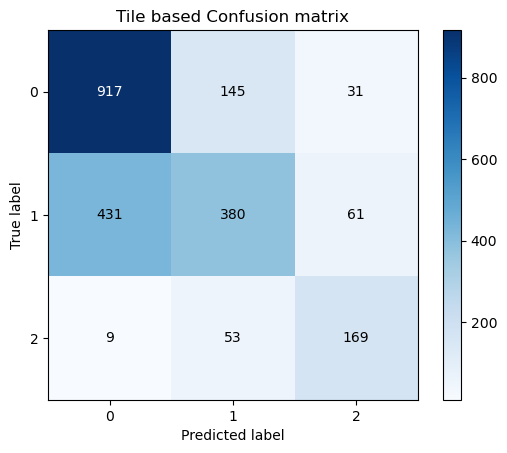

<Figure size 640x480 with 0 Axes>

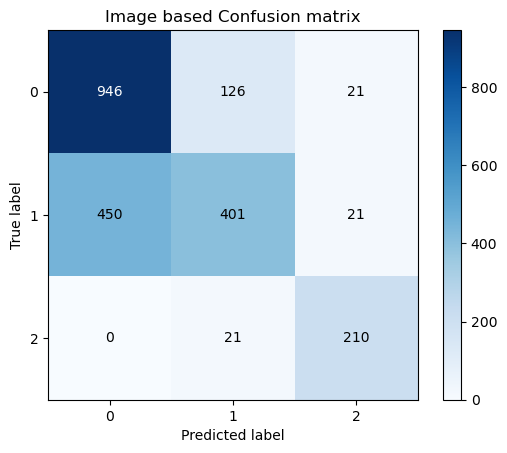

<Figure size 640x480 with 0 Axes>

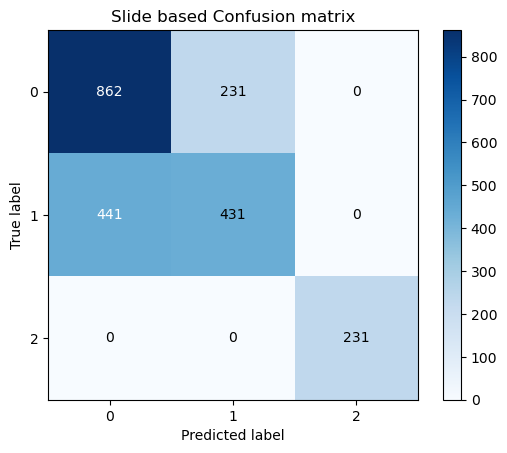

              precision    recall  f1-score   support

           0       0.68      0.84      0.75      1093
           1       0.66      0.44      0.52       872
           2       0.65      0.73      0.69       231

    accuracy                           0.67      2196
   macro avg       0.66      0.67      0.65      2196
weighted avg       0.67      0.67      0.65      2196

              precision    recall  f1-score   support

           0       0.68      0.87      0.76      1093
           1       0.73      0.46      0.56       872
           2       0.83      0.91      0.87       231

    accuracy                           0.71      2196
   macro avg       0.75      0.74      0.73      2196
weighted avg       0.72      0.71      0.69      2196

              precision    recall  f1-score   support

           0       0.66      0.79      0.72      1093
           1       0.65      0.49      0.56       872
           2       1.00      1.00      1.00       231

    accuracy        

C:\Users\salma\AppData\Local\Temp\ipykernel_20640\106536626.py:241: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)


<Figure size 640x480 with 0 Axes>

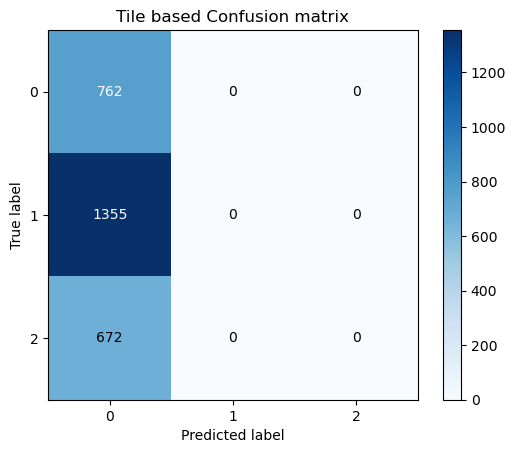

<Figure size 640x480 with 0 Axes>

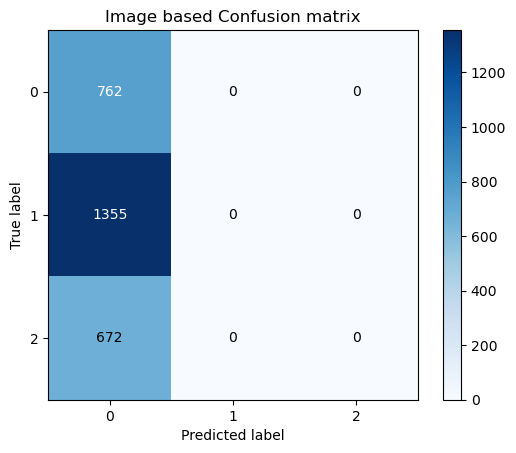

<Figure size 640x480 with 0 Axes>

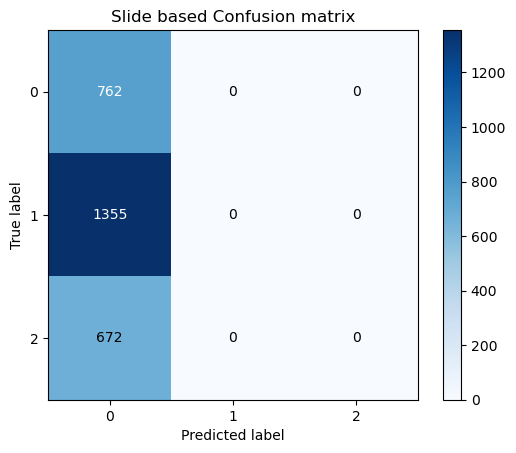

C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\

              precision    recall  f1-score   support

           0       0.27      1.00      0.43       762
           1       0.00      0.00      0.00      1355
           2       0.00      0.00      0.00       672

    accuracy                           0.27      2789
   macro avg       0.09      0.33      0.14      2789
weighted avg       0.07      0.27      0.12      2789

              precision    recall  f1-score   support

           0       0.27      1.00      0.43       762
           1       0.00      0.00      0.00      1355
           2       0.00      0.00      0.00       672

    accuracy                           0.27      2789
   macro avg       0.09      0.33      0.14      2789
weighted avg       0.07      0.27      0.12      2789

              precision    recall  f1-score   support

           0       0.27      1.00      0.43       762
           1       0.00      0.00      0.00      1355
           2       0.00      0.00      0.00       672

    accuracy        

C:\Users\salma\AppData\Local\Temp\ipykernel_20640\106536626.py:241: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)


<Figure size 640x480 with 0 Axes>

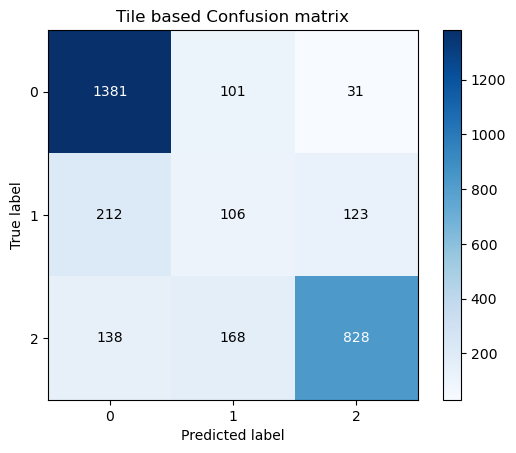

<Figure size 640x480 with 0 Axes>

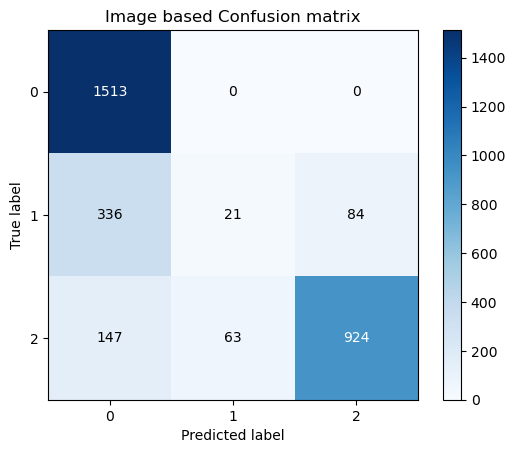

<Figure size 640x480 with 0 Axes>

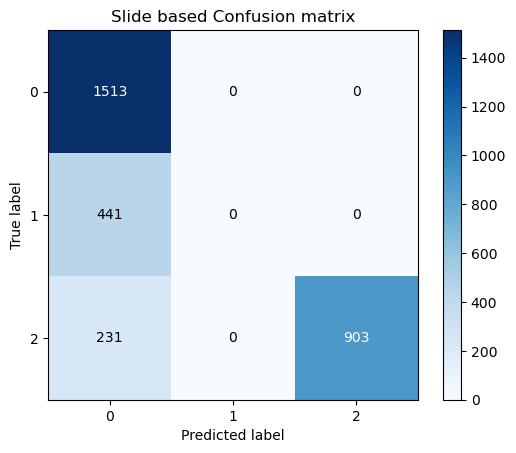

              precision    recall  f1-score   support

           0       0.80      0.91      0.85      1513
           1       0.28      0.24      0.26       441
           2       0.84      0.73      0.78      1134

    accuracy                           0.75      3088
   macro avg       0.64      0.63      0.63      3088
weighted avg       0.74      0.75      0.74      3088

              precision    recall  f1-score   support

           0       0.76      1.00      0.86      1513
           1       0.25      0.05      0.08       441
           2       0.92      0.81      0.86      1134

    accuracy                           0.80      3088
   macro avg       0.64      0.62      0.60      3088
weighted avg       0.74      0.80      0.75      3088

              precision    recall  f1-score   support

           0       0.69      1.00      0.82      1513
           1       0.00      0.00      0.00       441
           2       1.00      0.80      0.89      1134

    accuracy        

C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\

In [27]:
#n script for reading train and validation data set and train the network
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Conv2D, Flatten, Input, MaxPooling2D, Activation, BatchNormalization, Concatenate, Dropout, Add, Dense,LeakyReLU
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
import pandas as pd
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from keras.models import model_from_json
from myplot import multi_plot
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf
from tensorflow.keras.optimizers import SGD,RMSprop
from tensorflow.keras.applications import EfficientNetB0
from keras.applications.vgg16 import VGG16
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input
from keras.layers import Input, Flatten, Dense, Lambda
from keras.models import Model
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from keras.models import model_from_json
from myplot import multi_plot
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
import keras
import tensorflow as tf
from keras.callbacks import ModelCheckpoint
import pandas as pd
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.python.keras.layers import InputSpec, Layer

import pandas as pd
from sklearn.metrics import classification_report
from keras.models import Model, model_from_json

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve
#from sklearn.metrics import plot_precision_recall_curve
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
from tensorflow.keras.applications import EfficientNetB0,EfficientNetB4,EfficientNetB7
import os
##https://neptune.ai/blog/keras-metrics
from keras.callbacks import Callback
import matplotlib.pyplot as plt
import numpy as np
from scikitplot.metrics import plot_confusion_matrix, plot_roc, plot_precision_recall, plot_precision_recall_curve
######################################################################################################
class MulticlassTruePositives(tf.keras.metrics.Metric):
    def __init__(self, name='multiclass_true_positives', **kwargs):
        super(MulticlassTruePositives, self).__init__(name=name, **kwargs)
        self.true_positives = self.add_weight(name='tp', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.reshape(tf.argmax(y_pred, axis=1), shape=(-1, 1))
        values = tf.cast(y_true, 'int32') == tf.cast(y_pred, 'int32')
        values = tf.cast(values, 'float32')
        if sample_weight is not None:
            sample_weight = tf.cast(sample_weight, 'float32')
            values = tf.multiply(values, sample_weight)
        self.true_positives.assign_add(tf.reduce_sum(values))

    def result(self):
        return self.true_positives

    def reset_state(self):
        # The state of the metric will be reset at the start of each epoch.
        self.true_positives.assign(0.)

## Model definition
#################################################################################################################################
def pretrained_model_func(img_shape, num_classes,layer_type):
    inputs = tf.keras.Input(shape=(224,224,3))

    x = VGG16(
      input_tensor=inputs, 
      include_top=False,
      weights='imagenet' )

    x.trainable = False

    layer_type = 'relu'
    x = tf.keras.layers.Flatten(name='flatten')(x.output)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc1')(x)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc2')(x)
    x = tf.keras.layers.Dropout(0.5, name='dropout')(x)
    x = tf.keras.layers.Dense(3, activation='softmax', name='predictions')(x)



    METRICS = [
    keras.metrics.SparseCategoricalAccuracy(),
    MulticlassTruePositives()]



#Create your own model 
    pretrained_model = tf.keras.Model(inputs, x)
    pretrained_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=METRICS)
    return pretrained_model


#######################################################################

#validation_slide = ['ECMO','Control','ECMO+LPS','MV+LPS','MV']
validation_slide = ['1st_part','2nd_part','3rd_part']
model_name       = 'vgg_train_conv_min2_min3_relu'
### I took the best models in terms of TP 

tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
for val_s in validation_slide:
    val_dir          = val_s # loop over all groups as validation dataset
    Sample_Slide     = {'Control' : [9, 14, 15, 16, 17, 18, 19, 20, 26, 28, 46, 47],  
                    'MV+LPS'  : [35, 36, 41, 42, 43, 44, 45],
                    'ECMO+LPS': [1, 2 ,4, 5, 6, 7, 8, 25, 37, 38, 48],
                    'MV'      : [3, 10, 13, 28, 34],
                    'ECMO'    : [11, 12, 29, 30, 31, 32, 33, 39, 40, 49]}




    validation_DATA_PATH  = val_dir+'_validation/'
    validation_LABEL_PATH = 'analysed_data/All_samples_group_1_2_3_total_score_Median/'+val_dir+'_val_total_score/validation/validation_newlabels.txt'

    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_samples = np.zeros((n_v, input_shape[0], input_shape[1], 3), dtype=np.float32)
    validation_label = np.zeros((n_v,), int)

    # Reading true labels of validation set


    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
            
   
    for i in range(n_v):
        mod_img = validation_samples[i,:, :].astype(np.float32)
        validation_samples[i, :, :, :] = mod_img
    ##After we took all validation tiles we defined the model   

    pretrained_model = pretrained_model_func(input_shape, 3,'relu') ## REGRESSION: number of classes 1 instead of 3
    weights =glob.glob('../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_3_layer_relu/'+val_dir+'*.hdf5')[0]
    print(weights)
    # Load weights, select between best_weights (val_accuracy) and final_weights from last epoch
    #pretrained_model.load_weights(weights[0])
    ###############################################################################
    
    loaded_1 = keras.models.load_model(
        weights, custom_objects={"MulticlassTruePositives": MulticlassTruePositives,'Functional':EfficientNetB4()}
    )

    print(len(pretrained_model.get_weights())) ## this is model
    weights_list = loaded_1.get_weights()      ## This is weights
    print(len(weights_list))
    #model_index  = [475,476,478]   ### from model we have more layers (not top layers)
    #weight_index = [3,4,6]         ### This is for top layers only
    #for i,w in zip(model_index,weight_index):
    #    pretrained_model.layers[i].set_weights(loaded_1.layers[w].get_weights()) ## we set the layer weight by get weights 
        #from .h5 weights 
    #pretrained_model.layers[-7].set_weights([weights_list[-8],weights_list[-7]])
    #pretrained_model.layers[-8].set_weights([weights_list[-10],weights_list[-9]])
        
    pretrained_model.layers[-1].set_weights([weights_list[-2],weights_list[-1]])
    pretrained_model.layers[-3].set_weights([weights_list[-4],weights_list[-3]])
    pretrained_model.layers[-4].set_weights([weights_list[-6],weights_list[-5]])
    pretrained_model.layers[-7].set_weights([weights_list[-8],weights_list[-7]])
    pretrained_model.layers[-8].set_weights([weights_list[-10],weights_list[-9]])
    pretrained_model.layers[-9].set_weights([weights_list[-12],weights_list[-11]])
    
    
    
    
    ###############################################################################
    # Make predictions on validation samples
    #with tf.device('/CPU:0'):
    preds = pretrained_model.predict(validation_samples)
    
    # Max predictions in numpy array
    y_pred = np.argmax(preds,axis=1)  # 0,1 or 2
    x_l = range(len(y_pred))

    ################################################################
    ### Here all predicted labels are saved in the following file
    with open(validation_LABEL_PATH,'r') as f: 
        with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','w') as fout: 
            for i,line in zip(y_pred,f):
                print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)
        fout.close()
    f.close()


    ### This is for extracting slide number from images to add
    keys = []
    Slide_dict = {}
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            S_num = str(line.split(' ')[0][6:8])
            if '.' in S_num:
                S_num = S_num.replace('.','')
            if '_' in S_num:
                S_num = S_num.replace('_','')
            if S_num not in keys:
                keys.append(S_num)
                Slide_dict[S_num]=[]

    fout.close()
    #########################################################
    ### Add all scores of tiles to the slide key
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=line.split(' ')[0][6:8]
            if '.' in key_temp:
                key_temp = key_temp.replace('.','')
            if '_' in key_temp:
                key_temp = key_temp.replace('_','')
           
            Slide_dict[key_temp].append(float(line.split(' ')[1].strip()))

    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_slide = np.ones(len(y_pred))  
    offset = 0
    for k in Slide_dict.keys():
        class_0 = [index for index, element in enumerate(Slide_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Slide_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Slide_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_slide[offset:offset+len(Slide_dict[k])]= majority_vote
        #print(y_pred_slide[offset:offset+len(Slide_dict[k])])
        offset += len(Slide_dict[k])
    ################################################################
    
    ### Add all scores of tiles to the Image name key
    keys = []
    Image_dict = {}
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            I_num = str(line.split('___')[0])
            if I_num not in keys:
                keys.append(I_num)
                Image_dict[I_num]=[]

    fout.close()
    
   
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=str(line.split('___')[0])
            Image_dict[key_temp].append(float(line.split(' ')[1].strip()))

    #print(Image_dict.keys())
    
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_image = np.ones(len(y_pred))  
    offset = 0
    for k in Image_dict.keys():
        class_0 = [index for index, element in enumerate(Image_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Image_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Image_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_image[offset:offset+len(Image_dict[k])]= majority_vote
        #print(y_pred_image[offset:offset+len(Image_dict[k])])
        offset += len(Image_dict[k])

    

    #############################
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred)
    plt.title('Tile based Confusion matrix')
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_image)
    plt.title('Image based Confusion matrix')
    
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_slide)
    plt.title('Slide based Confusion matrix')
    
    plt.show()

    



    print(classification_report(precise_scores,y_pred))
    print(classification_report(precise_scores,y_pred_image))
    print(classification_report(precise_scores,y_pred_slide))
    
    
    tile_based_scores[val_dir]  = pd.DataFrame(classification_report(precise_scores,y_pred,output_dict=True)).transpose()
    image_based_scores[val_dir] = pd.DataFrame(classification_report(precise_scores,y_pred_image,output_dict=True)).transpose()
    slide_based_scores[val_dir] = pd.DataFrame(classification_report(precise_scores,y_pred_slide,output_dict=True)).transpose()
    

df_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])

df_image = pd.concat([image_based_scores['1st_part'], image_based_scores['2nd_part'],image_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])

df_slide = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])


df_tile.to_csv('predict_result_3cv/'+model_name+'_tiles.csv')

df_image.to_csv('predict_result_3cv/'+model_name+'_image.csv')

df_slide.to_csv('predict_result_3cv/'+model_name+'_slide.csv')

dict_keys(['Slide9', 'slide14', 'slide15', 'slide16', 'Slide3', 'Slide1', 'Slide2', 'Slide4', 'Slide11', 'Slide12', 'Slide29', 'slide35', 'slide36'])


<Figure size 640x480 with 0 Axes>

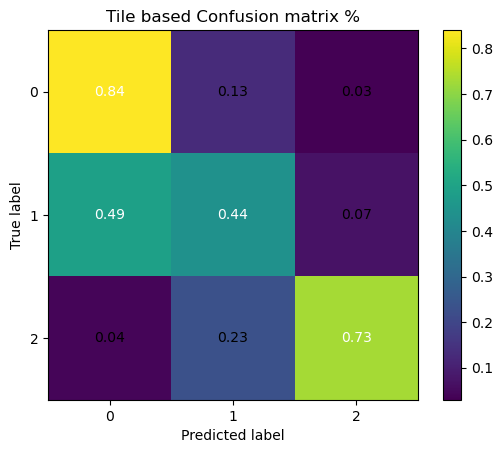

<Figure size 640x480 with 0 Axes>

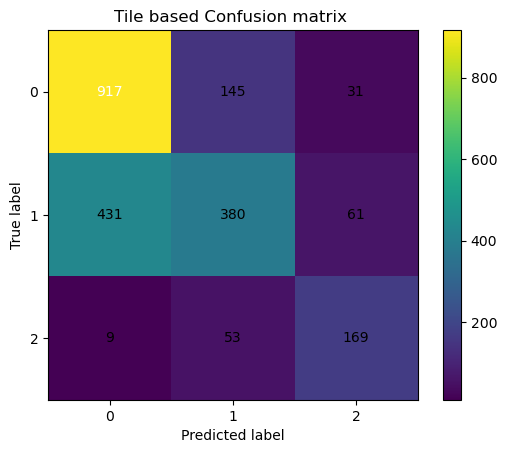

<Figure size 640x480 with 0 Axes>

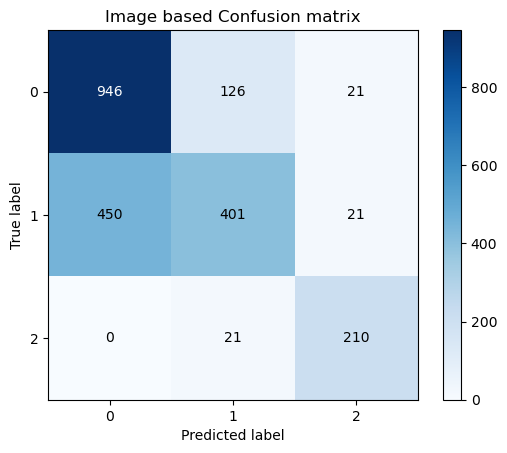

<Figure size 640x480 with 0 Axes>

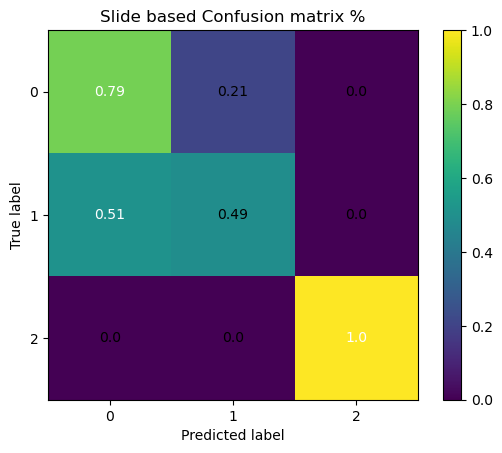

<Figure size 640x480 with 0 Axes>

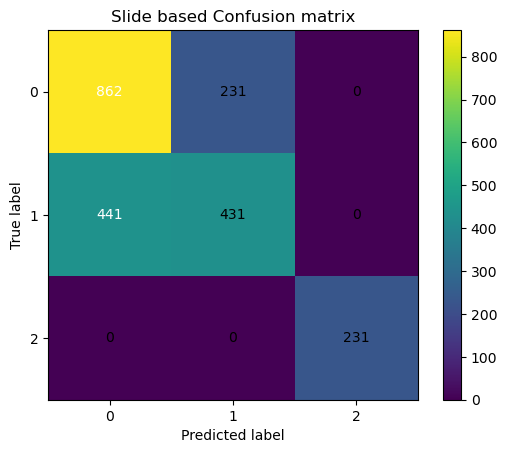

dict_keys(['slide17', 'slide18', 'slide19', 'slide20', 'Slide10', 'Slide13', 'Slide5', 'Slide6', 'Slide7', 'Slide8', 'Slide30', 'Slide31', 'Slide32', 'Slide42', 'slide41'])


<Figure size 640x480 with 0 Axes>

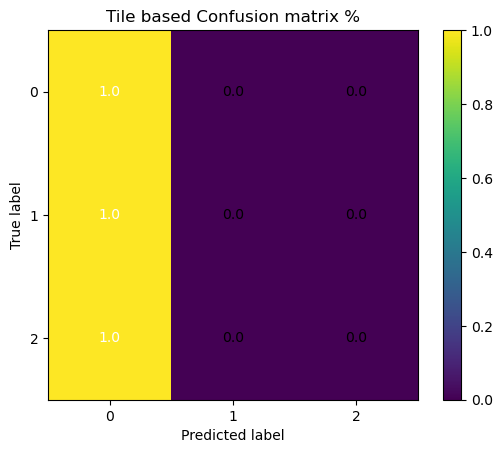

<Figure size 640x480 with 0 Axes>

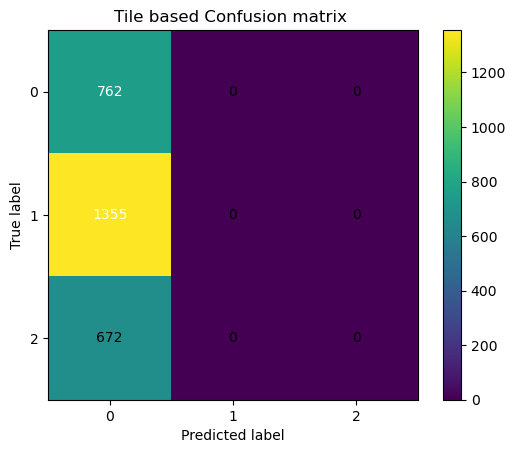

<Figure size 640x480 with 0 Axes>

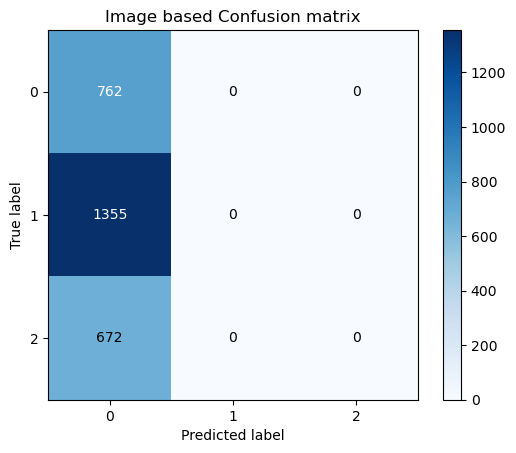

<Figure size 640x480 with 0 Axes>

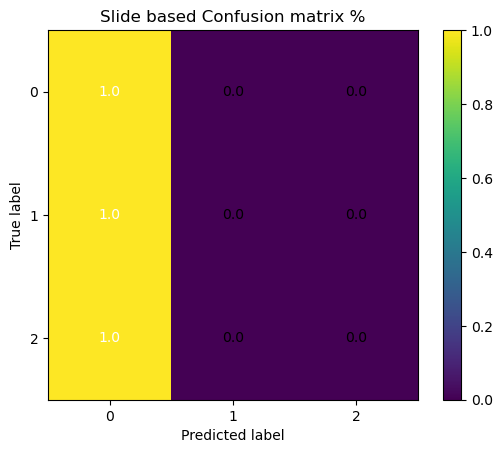

<Figure size 640x480 with 0 Axes>

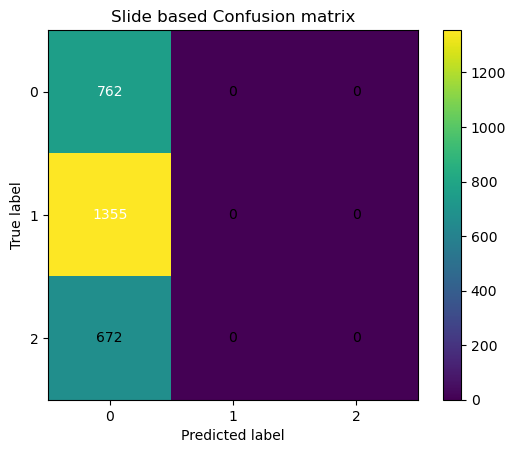

C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn

dict_keys(['slide26', 'slide28', 'slide46', 'slide47', 'Slide28', 'Slide34', 'Slide25', 'Slide37', 'Slide38', 'Slide48', 'Slide33', 'Slide39', 'Slide40', 'Slide49', 'Slide43', 'Slide45', 'slide44'])


<Figure size 640x480 with 0 Axes>

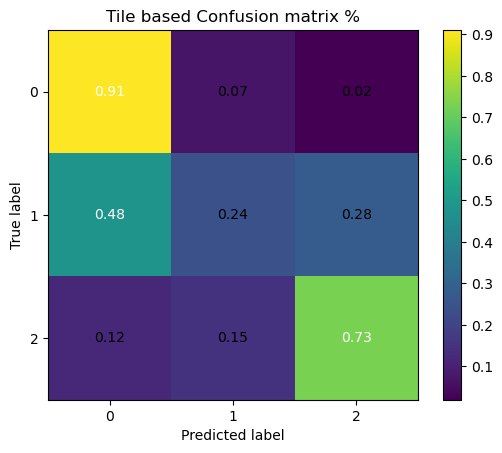

<Figure size 640x480 with 0 Axes>

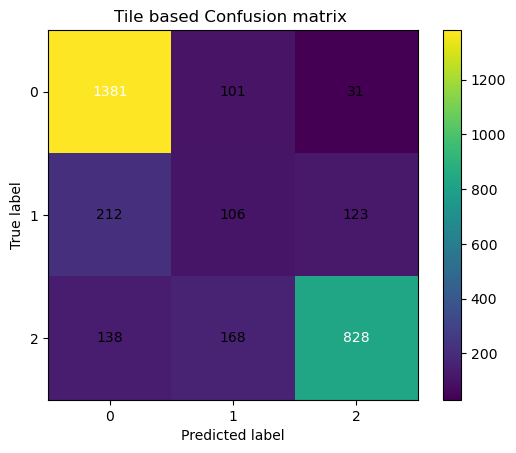

<Figure size 640x480 with 0 Axes>

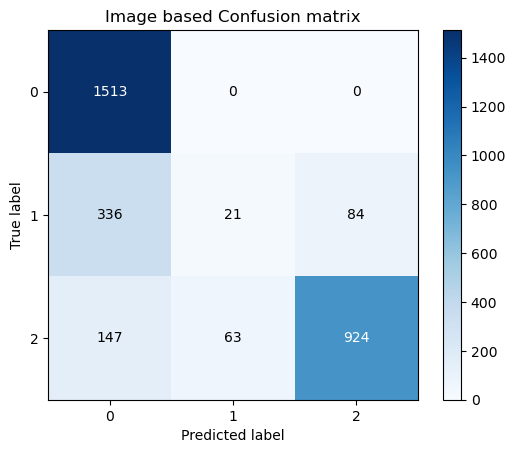

<Figure size 640x480 with 0 Axes>

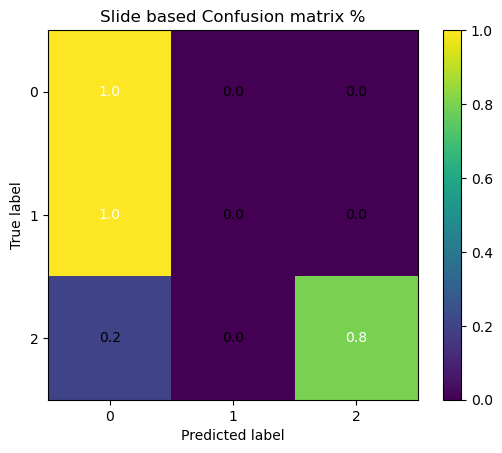

<Figure size 640x480 with 0 Axes>

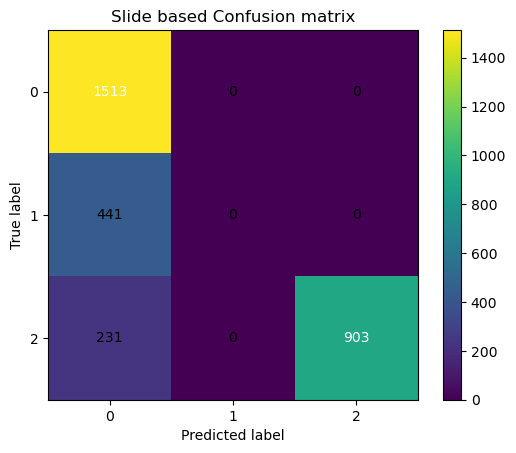

C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\AppData\Local\Temp\ipykernel_20640\1603314512.py:319: RuntimeWarning: invalid value encountered in divide
  f1_score_col = (prec_col*rec_col*2) / (prec_col+rec_col)


fold1                         fold2                      \
                 Precision    Recall  F1-score Precision    Recall  F1-score   
Low               0.661550  0.788655  0.719533  0.273216  1.000000  0.429175   
Medium            0.651057  0.494266  0.561930  0.000000  0.000000       NaN   
High              1.000000  1.000000  1.000000  0.000000  0.000000       NaN   
Micro_average     0.693989  0.693989  0.693989  0.273216  0.273216  0.273216   
weighted_average  0.692986  0.693989  0.693487  0.074647  0.273216  0.117258   

                     fold3                       Average                      
                 Precision    Recall  F1-score Precision    Recall  F1-score  
Low               0.692449  1.000000  0.818280  0.542405  0.929552  0.685066  
Medium            0.000000  0.000000       NaN  0.217019  0.164755  0.187310  
High              1.000000  0.796296  0.886598  0.666667  0.598765  0.630894  
Micro_average     0.782383  0.782383  0.782383  0.583196  0.583196  0.583196  
weighted_average  0.706501  0.782383  0.742508  0.491378  0.583196  0.533364

In [28]:
import glob
import matplotlib.pyplot as plt
import numpy as np


from sklearn.metrics import precision_score, recall_score, f1_score,multilabel_confusion_matrix
from sklearn.metrics import precision_recall_curve
#from sklearn.metrics import plot_precision_recall_curve
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
from scikitplot.metrics import plot_confusion_matrix, plot_roc, plot_precision_recall, plot_precision_recall_curve


validation_slide = ['1st_part','2nd_part','3rd_part']
model_name       = 'vgg_train_conv_min2_min3_relu'

tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
##Normalized thresholds
low = (10-(min_score))/(max_score-min_score)
mid = (25-(min_score))/(max_score-min_score)
for val_dir in validation_slide:
    validation_DATA_PATH  = val_dir+'_validation/'
    validation_LABEL_PATH = 'analysed_data/All_samples_group_1_2_3_total_score_Median/'+val_dir+'_val_total_score/validation/validation_newlabels.txt'

  
    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_label = np.zeros((n_v,), int)
    
    ######################################################################################################
    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            #validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
    
############################################################################################################    
    y_pred = []  
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as f:
        for line in f:
            y_pred.append(int(line.split(' ')[1].strip()))  

   ##############################################################################################    
    keys = []
    Slide_dict = {}
    flag_28  = False
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            S_num = str(line.split(' ')[0][0:8])
            if '.' in S_num:
                S_num = S_num.replace('.','')
            if '_' in S_num:
                S_num = S_num.replace('_','')
            if S_num not in keys:
                keys.append(S_num)
                Slide_dict[S_num]=[]

    fout.close()
    #########################################################
    ### Add all scores of tiles to the slide key
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=line.split(' ')[0][0:8]
            if '.' in key_temp:
                key_temp = key_temp.replace('.','')
            if '_' in key_temp:
                key_temp = key_temp.replace('_','')
           
            Slide_dict[key_temp].append(float(line.split(' ')[1].strip()))
    print(Slide_dict.keys())
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_slide = np.ones(len(y_pred))  
    offset = 0
    for k in Slide_dict.keys():
        class_0 = [index for index, element in enumerate(Slide_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Slide_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Slide_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_slide[offset:offset+len(Slide_dict[k])]= majority_vote
        #print(y_pred_slide[offset:offset+len(Slide_dict[k])])
        offset += len(Slide_dict[k])
    ################################################################
    
    ### Add all scores of tiles to the Image name key
    keys = []
    Image_dict = {}
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            I_num = str(line.split('___')[0])
            if I_num not in keys:
                keys.append(I_num)
                Image_dict[I_num]=[]

    fout.close()
    
   
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=str(line.split('___')[0])
            Image_dict[key_temp].append(float(line.split(' ')[1].strip()))

    #print(Image_dict.keys())
    
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_image = np.ones(len(y_pred))  
    offset = 0
    for k in Image_dict.keys():
        class_0 = [index for index, element in enumerate(Image_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Image_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Image_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_image[offset:offset+len(Image_dict[k])]= majority_vote
        #print(y_pred_image[offset:offset+len(Image_dict[k])])
        offset += len(Image_dict[k])

    

    #############################
    my_bins = [0, 1, 2]
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred,labels=my_bins,normalize='true', cmap='viridis')
    plt.title('Tile based Confusion matrix %')
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred,labels=my_bins, cmap='viridis')
    plt.title('Tile based Confusion matrix ')
    
    
    
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_image,labels=my_bins)
    plt.title('Image based Confusion matrix')
    
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_slide,labels=my_bins,normalize='true', cmap='viridis')
    plt.title('Slide based Confusion matrix %')
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_slide,labels=my_bins, cmap='viridis')
    plt.title('Slide based Confusion matrix')
    
    plt.show()

    
    
    

    tile_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','weighted_average'],
                                               columns=['Precision','Recall','F1-score'])
   #############################
    prec_col = np.zeros((1,5))
    tile_classes = precision_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = precision_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = precision_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    tile_weighted = precision_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = tile_classes
    prec_col[0,3] = tile_Micro
    #prec_col[0,4] = tile_Macro
    prec_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    #############################
    rec_col = np.zeros((1,5))
    tile_classes = recall_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = recall_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = recall_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    tile_weighted = recall_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    rec_col[0,0:3] = tile_classes
    rec_col[0,3] = tile_Micro
    #rec_col[0,4] = tile_Macro
    rec_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #############################
     #############################
    f1_score_col = np.zeros((1,5))
    tile_classes = f1_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = f1_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = f1_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    tile_weighted =  f1_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    f1_score_col[0,0:3] = tile_classes
    f1_score_col[0,3] = tile_Micro
    #f1_score_col[0,4] = tile_Macro
    f1_score_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
    #############################
#################################################################################################################    
       #############################

    #############################
#################################################################################################################    
    image_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','Macro_average','weighted_average'],columns=['Precision','Recall','F1-score','support'])
   #############################
    prec_col = np.zeros((1,6))
    image_classes = precision_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = precision_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = precision_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted = precision_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = image_classes
    prec_col[0,3] = image_Micro
    prec_col[0,4] = image_Macro
    prec_col[0,5] = image_weighted
    image_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    #############################
    rec_col = np.zeros((1,6))
    image_classes = recall_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = recall_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = recall_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted = recall_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    rec_col[0,0:3] = image_classes
    rec_col[0,3] = image_Micro
    rec_col[0,4] = image_Macro
    rec_col[0,5] = image_weighted
    image_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #############################
     #############################
    f1_score_col = np.zeros((1,6))
    image_classes = f1_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = f1_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = f1_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted =  f1_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    f1_score_col[0,0:3] = image_classes
    f1_score_col[0,3] = image_Micro
    f1_score_col[0,4] = image_Macro
    f1_score_col[0,5] = image_weighted
    f1_score_col = (prec_col*rec_col*2) / (prec_col+rec_col)
    image_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
    #############################
#################################################################################################################    
    supprt_col = np.zeros((1,6))
    image_class0 = np.sum(np.array(precise_scores) == 0)
    image_class1 = np.sum(np.array(precise_scores) == 1)
    image_class2 = np.sum(np.array(precise_scores) == 2)
    
    image_Micro    = len(precise_scores)
    image_Macro    = len(precise_scores)
    image_weighted = len(precise_scores)
    
    supprt_col[0,0] = image_class0
    supprt_col[0,1] = image_class1
    supprt_col[0,2] = image_class2
    
    supprt_col[0,3] = image_Micro
    supprt_col[0,4] = image_Macro
    supprt_col[0,5] = image_weighted
    image_based_scores[val_dir]['support']  =  supprt_col.transpose()
    
    
    #############################
    slide_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','weighted_average'],
                                                columns=['Precision','Recall','F1-score'])
   #############################
    prec_col = np.zeros((1,5))
    slide_classes = precision_score(precise_scores,y_pred_slide, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    slide_Micro = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='micro', zero_division='warn')
    #slide_Macro = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='macro', zero_division='warn')
    slide_weighted = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = slide_classes
    prec_col[0,3] = slide_Micro
    #prec_col[0,4] = slide_Macro
    prec_col[0,4] = slide_weighted
    slide_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    #############################
    rec_col = np.zeros((1,5))
    slide_classes = recall_score(precise_scores,y_pred_slide, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    slide_Micro = recall_score(precise_scores,y_pred_slide, sample_weight=None,average='micro', zero_division='warn')
    #slide_Macro = recall_score(precise_scores,y_pred_slide, sample_weight=None,average='macro', zero_division='warn')
    slide_weighted = recall_score(precise_scores,y_pred_slide,average='weighted', zero_division='warn')
    
    rec_col[0,0:3] = slide_classes
    rec_col[0,3] = slide_Micro
    #rec_col[0,4] = slide_Macro
    rec_col[0,4] = slide_weighted
    slide_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #############################
    f1_score_col = np.zeros((1,5))
    #slide_classes = f1_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    #slide_Micro = f1_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = f1_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    #slide_weighted =  f1_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    #f1_score_col[0,0:3] = slide_classes
    #f1_score_col[0,3] = slide_Micro
    #f1_score_col[0,4] = tile_Macro
    #f1_score_col[0,4] = slide_weighted
    f1_score_col = (prec_col*rec_col*2) / (prec_col+rec_col)
    slide_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
     #############################
        #############################
#################################################################################################################    
 ################################################################################################
df_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part']], axis=1,
                     keys=['fold1','fold2','fold3'])

df_img  = pd.concat([image_based_scores['1st_part'], image_based_scores['2nd_part'],image_based_scores['3rd_part']], axis=1,
                     keys=['fold1','fold2','fold3'])

df_slide  = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part']], axis=1,
                       keys=['fold1','fold2','fold3'])

#################################################################################################

df_1_tile = np.array(df_tile.iloc[0:6,0:3]).astype(float)
df_2_tile = np.array(df_tile.iloc[0:6,3:6]).astype(float)
df_3_tile = np.array(df_tile.iloc[0:6,6:9]).astype(float)





a = [df_1_tile,df_2_tile,df_3_tile]



tile_mean = np.mean(a,axis=0)


tile_m = pd.DataFrame(tile_mean,columns= ['Precision','Recall','F1-score'],index = ['Low','Medium','High','Micro_average','weighted_average'])
tile_m


tile_m['F1-score'] = (2*tile_m['Precision']*tile_m['Recall'])/(tile_m['Precision']+tile_m['Recall'])

tile_m
############################################################################################


df_1_img = np.array(df_img.iloc[0:7,0:3]).astype(float)
df_2_img = np.array(df_img.iloc[0:7,4:7]).astype(float)
df_3_img = np.array(df_img.iloc[0:7,8:11]).astype(float)


weights_1 = np.array(df_img.iloc[0:7,3]).astype(float)*np.identity(6)
weights_2 = np.array(df_img.iloc[0:7,7]).astype(float)*np.identity(6)
weights_3 = np.array(df_img.iloc[0:7,11]).astype(float)*np.identity(6)

sum_weights = np.matmul((weights_1+weights_2+weights_3),np.ones([6,1]))



b = [np.matmul(weights_1/sum_weights,df_1_img),np.matmul(weights_2/sum_weights,df_2_img),
    np.matmul(weights_3/sum_weights,df_3_img)]


img_mean = np.sum(b,axis=0)
img_m = pd.DataFrame(img_mean,columns= ['precision','recall','f1-score'],index = ['Low','Medium','High','Micro_average','Macro_average','weighted_average'])
img_m

###################################################################################################

#df_1_slide = np.array(df_slide.iloc[0:6,0:2]).astype(float)
#df_2_slide = np.array(df_slide.iloc[0:6,2:4]).astype(float)
#df_3_slide = np.array(df_slide.iloc[0:6,4:6]).astype(float)

df_1_slide = np.array(df_slide.iloc[0:6,0:3]).astype(float)
df_2_slide = np.array(df_slide.iloc[0:6,3:6]).astype(float)
df_3_slide = np.array(df_slide.iloc[0:6,6:9]).astype(float)





a = [df_1_slide,df_2_slide,df_3_slide]



slide_mean = np.mean(a,axis=0)
slide_m = pd.DataFrame(slide_mean,columns= ['Precision','Recall','F1-score'],
                       index = ['Low','Medium','High','Micro_average','weighted_average'])

slide_m['F1-score'] = (2*slide_m['Precision']*slide_m['Recall'])/(slide_m['Precision']+slide_m['Recall'])


#df_vgg_man_aug_tile = pd.concat([df_tile['fold1'],df_tile['fold2'],df_tile['fold3'],tile_m],axis=1,keys=['fold1,fold2,fold3','Average'])
#df_vgg_man_aug_tile
df_vgg_train_conv_min2_min3_relu_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part'],tile_m], axis=1,keys=['fold1','fold2','fold3','Average'])
df_vgg_train_conv_min2_min3_relu_tile

df_vgg_train_conv_min2_min3_relu_slide  = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part'],slide_m], axis=1,keys=['fold1','fold2','fold3','Average'])
df_vgg_train_conv_min2_min3_relu_slide



### next cell EffnetB4 + layer (-2,-3) conv + LeakyReLU

../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_3_layer_LeakyReLU\1st_part_best_weights.13-1.06.hdf5
32
32


C:\Users\salma\AppData\Local\Temp\ipykernel_20640\415326839.py:241: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)


<Figure size 640x480 with 0 Axes>

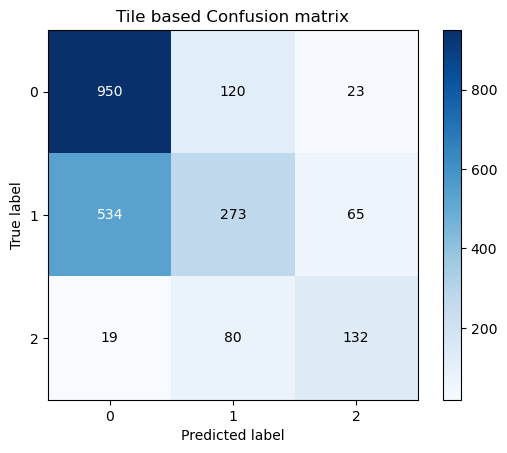

<Figure size 640x480 with 0 Axes>

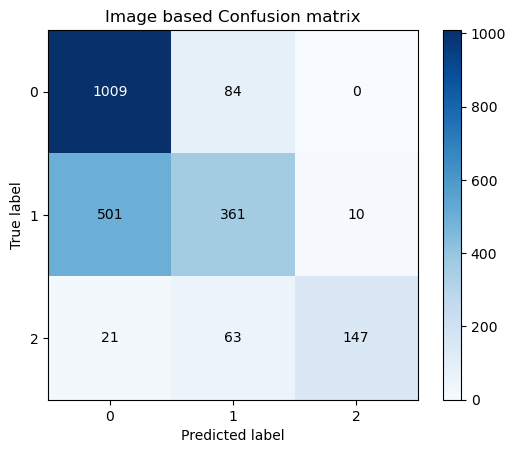

<Figure size 640x480 with 0 Axes>

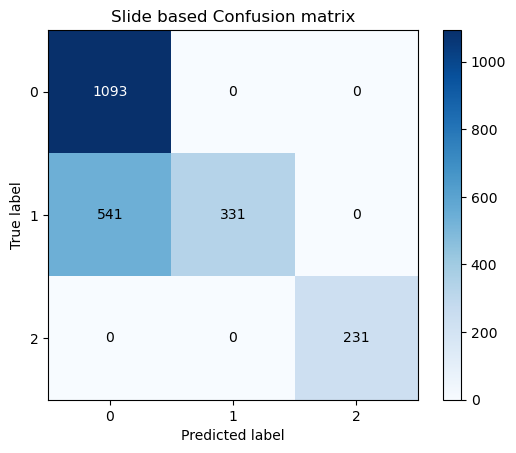

              precision    recall  f1-score   support

           0       0.63      0.87      0.73      1093
           1       0.58      0.31      0.41       872
           2       0.60      0.57      0.59       231

    accuracy                           0.62      2196
   macro avg       0.60      0.58      0.57      2196
weighted avg       0.61      0.62      0.59      2196

              precision    recall  f1-score   support

           0       0.66      0.92      0.77      1093
           1       0.71      0.41      0.52       872
           2       0.94      0.64      0.76       231

    accuracy                           0.69      2196
   macro avg       0.77      0.66      0.68      2196
weighted avg       0.71      0.69      0.67      2196

              precision    recall  f1-score   support

           0       0.67      1.00      0.80      1093
           1       1.00      0.38      0.55       872
           2       1.00      1.00      1.00       231

    accuracy        

C:\Users\salma\AppData\Local\Temp\ipykernel_20640\415326839.py:241: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)


<Figure size 640x480 with 0 Axes>

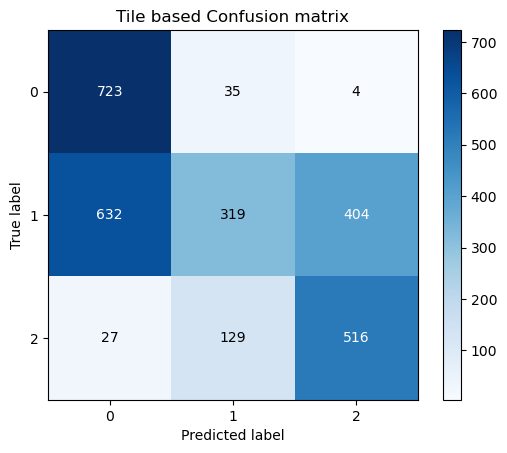

<Figure size 640x480 with 0 Axes>

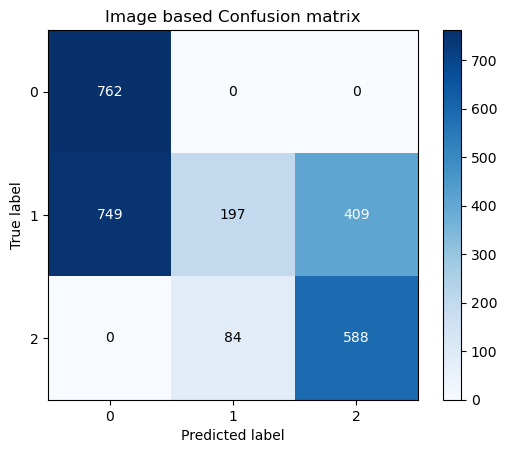

<Figure size 640x480 with 0 Axes>

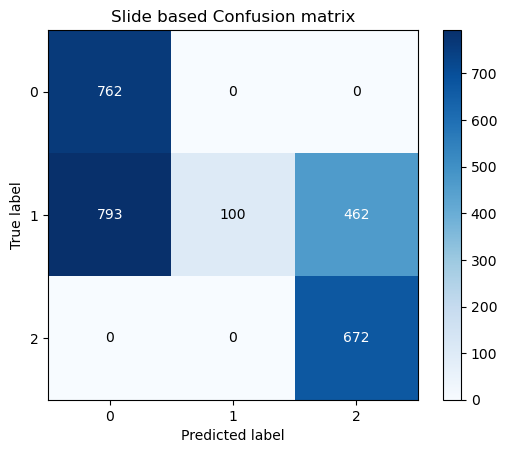

              precision    recall  f1-score   support

           0       0.52      0.95      0.67       762
           1       0.66      0.24      0.35      1355
           2       0.56      0.77      0.65       672

    accuracy                           0.56      2789
   macro avg       0.58      0.65      0.56      2789
weighted avg       0.60      0.56      0.51      2789

              precision    recall  f1-score   support

           0       0.50      1.00      0.67       762
           1       0.70      0.15      0.24      1355
           2       0.59      0.88      0.70       672

    accuracy                           0.55      2789
   macro avg       0.60      0.67      0.54      2789
weighted avg       0.62      0.55      0.47      2789

              precision    recall  f1-score   support

           0       0.49      1.00      0.66       762
           1       1.00      0.07      0.14      1355
           2       0.59      1.00      0.74       672

    accuracy        

C:\Users\salma\AppData\Local\Temp\ipykernel_20640\415326839.py:241: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)


<Figure size 640x480 with 0 Axes>

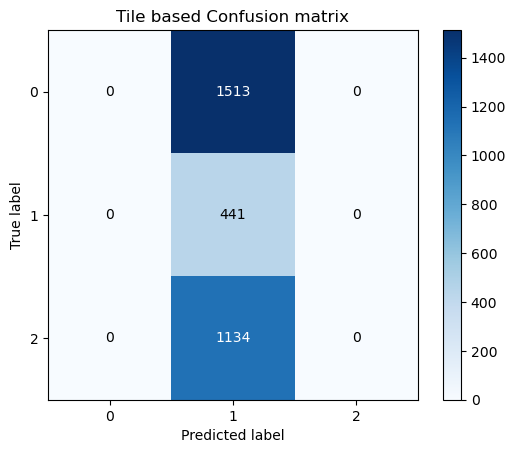

<Figure size 640x480 with 0 Axes>

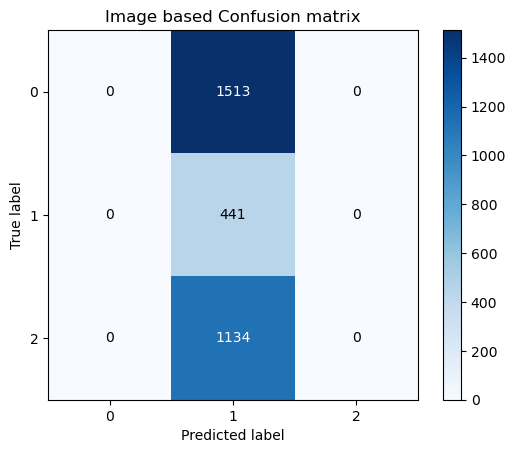

<Figure size 640x480 with 0 Axes>

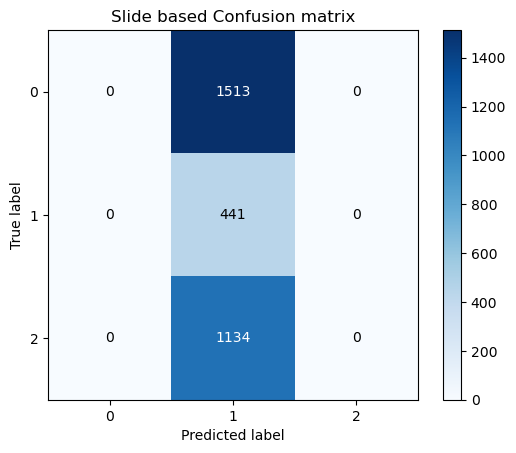

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1513
           1       0.14      1.00      0.25       441
           2       0.00      0.00      0.00      1134

    accuracy                           0.14      3088
   macro avg       0.05      0.33      0.08      3088
weighted avg       0.02      0.14      0.04      3088

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1513
           1       0.14      1.00      0.25       441
           2       0.00      0.00      0.00      1134

    accuracy                           0.14      3088
   macro avg       0.05      0.33      0.08      3088
weighted avg       0.02      0.14      0.04      3088

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1513
           1       0.14      1.00      0.25       441
           2       0.00      0.00      0.00      1134

    accuracy        

C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\

In [29]:
#n script for reading train and validation data set and train the network
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Conv2D, Flatten, Input, MaxPooling2D, Activation, BatchNormalization, Concatenate, Dropout, Add, Dense,LeakyReLU
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
import pandas as pd
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from keras.models import model_from_json
from myplot import multi_plot
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf
from tensorflow.keras.optimizers import SGD,RMSprop
from tensorflow.keras.applications import EfficientNetB0
from keras.applications.vgg16 import VGG16
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input
from keras.layers import Input, Flatten, Dense, Lambda
from keras.models import Model
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from keras.models import model_from_json
from myplot import multi_plot
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
import keras
import tensorflow as tf
from keras.callbacks import ModelCheckpoint
import pandas as pd
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.python.keras.layers import InputSpec, Layer

import pandas as pd
from sklearn.metrics import classification_report
from keras.models import Model, model_from_json

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve
#from sklearn.metrics import plot_precision_recall_curve
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
from tensorflow.keras.applications import EfficientNetB0,EfficientNetB4,EfficientNetB7
import os
##https://neptune.ai/blog/keras-metrics
from keras.callbacks import Callback
import matplotlib.pyplot as plt
import numpy as np
from scikitplot.metrics import plot_confusion_matrix, plot_roc, plot_precision_recall, plot_precision_recall_curve
######################################################################################################
class MulticlassTruePositives(tf.keras.metrics.Metric):
    def __init__(self, name='multiclass_true_positives', **kwargs):
        super(MulticlassTruePositives, self).__init__(name=name, **kwargs)
        self.true_positives = self.add_weight(name='tp', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.reshape(tf.argmax(y_pred, axis=1), shape=(-1, 1))
        values = tf.cast(y_true, 'int32') == tf.cast(y_pred, 'int32')
        values = tf.cast(values, 'float32')
        if sample_weight is not None:
            sample_weight = tf.cast(sample_weight, 'float32')
            values = tf.multiply(values, sample_weight)
        self.true_positives.assign_add(tf.reduce_sum(values))

    def result(self):
        return self.true_positives

    def reset_state(self):
        # The state of the metric will be reset at the start of each epoch.
        self.true_positives.assign(0.)

## Model definition
#################################################################################################################################
def pretrained_model_func(img_shape, num_classes,layer_type):
    inputs = tf.keras.Input(shape=(224,224,3))

    x = VGG16(
      input_tensor=inputs, 
      include_top=False,
      weights='imagenet' )

    x.trainable = False

    layer_type = LeakyReLU(0.2)
    x = tf.keras.layers.Flatten(name='flatten')(x.output)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc1')(x)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc2')(x)
    x = tf.keras.layers.Dropout(0.5, name='dropout')(x)
    x = tf.keras.layers.Dense(3, activation='softmax', name='predictions')(x)



    METRICS = [
    keras.metrics.SparseCategoricalAccuracy(),
    MulticlassTruePositives()]



#Create your own model 
    pretrained_model = tf.keras.Model(inputs, x)
    pretrained_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=METRICS)
    return pretrained_model


#######################################################################

#validation_slide = ['ECMO','Control','ECMO+LPS','MV+LPS','MV']
validation_slide = ['1st_part','2nd_part','3rd_part']
model_name       = 'vgg_train_conv_min2_min3_Leakyrelu'
### I took the best models in terms of TP 

tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
for val_s in validation_slide:
    val_dir          = val_s # loop over all groups as validation dataset
    Sample_Slide     = {'Control' : [9, 14, 15, 16, 17, 18, 19, 20, 26, 28, 46, 47],  
                    'MV+LPS'  : [35, 36, 41, 42, 43, 44, 45],
                    'ECMO+LPS': [1, 2 ,4, 5, 6, 7, 8, 25, 37, 38, 48],
                    'MV'      : [3, 10, 13, 28, 34],
                    'ECMO'    : [11, 12, 29, 30, 31, 32, 33, 39, 40, 49]}




    validation_DATA_PATH  = val_dir+'_validation/'
    validation_LABEL_PATH = 'analysed_data/All_samples_group_1_2_3_total_score_Median/'+val_dir+'_val_total_score/validation/validation_newlabels.txt'

    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_samples = np.zeros((n_v, input_shape[0], input_shape[1], 3), dtype=np.float32)
    validation_label = np.zeros((n_v,), int)

    # Reading true labels of validation set


    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
            
   
    for i in range(n_v):
        mod_img = validation_samples[i,:, :].astype(np.float32)
        validation_samples[i, :, :, :] = mod_img
    ##After we took all validation tiles we defined the model   

    pretrained_model = pretrained_model_func(input_shape, 3,LeakyReLU(0.2)) ## REGRESSION: number of classes 1 instead of 3
    weights =glob.glob('../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_3_layer_LeakyReLU/'+val_dir+'*.hdf5')[0]
    print(weights)
    # Load weights, select between best_weights (val_accuracy) and final_weights from last epoch
    #pretrained_model.load_weights(weights[0])
    ###############################################################################
    
    loaded_1 = keras.models.load_model(
        weights, custom_objects={"MulticlassTruePositives": MulticlassTruePositives,'Functional':EfficientNetB4()}
    )

    print(len(pretrained_model.get_weights())) ## this is model
    weights_list = loaded_1.get_weights()      ## This is weights
    print(len(weights_list))
    #model_index  = [475,476,478]   ### from model we have more layers (not top layers)
    #weight_index = [3,4,6]         ### This is for top layers only
    #for i,w in zip(model_index,weight_index):
    #    pretrained_model.layers[i].set_weights(loaded_1.layers[w].get_weights()) ## we set the layer weight by get weights 
        #from .h5 weights 
    #pretrained_model.layers[-7].set_weights([weights_list[-8],weights_list[-7]])
    #pretrained_model.layers[-8].set_weights([weights_list[-10],weights_list[-9]])
        
    pretrained_model.layers[-1].set_weights([weights_list[-2],weights_list[-1]])
    pretrained_model.layers[-3].set_weights([weights_list[-4],weights_list[-3]])
    pretrained_model.layers[-4].set_weights([weights_list[-6],weights_list[-5]])
    pretrained_model.layers[-7].set_weights([weights_list[-8],weights_list[-7]])
    pretrained_model.layers[-8].set_weights([weights_list[-10],weights_list[-9]])
    pretrained_model.layers[-9].set_weights([weights_list[-12],weights_list[-11]])
    
    
    
    
    ###############################################################################
    # Make predictions on validation samples
    #with tf.device('/CPU:0'):
    preds = pretrained_model.predict(validation_samples)
    
    # Max predictions in numpy array
    y_pred = np.argmax(preds,axis=1)  # 0,1 or 2
    x_l = range(len(y_pred))

    ################################################################
    ### Here all predicted labels are saved in the following file
    with open(validation_LABEL_PATH,'r') as f: 
        with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','w') as fout: 
            for i,line in zip(y_pred,f):
                print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)
        fout.close()
    f.close()


    ### This is for extracting slide number from images to add
    keys = []
    Slide_dict = {}
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            S_num = str(line.split(' ')[0][6:8])
            if '.' in S_num:
                S_num = S_num.replace('.','')
            if '_' in S_num:
                S_num = S_num.replace('_','')
            if S_num not in keys:
                keys.append(S_num)
                Slide_dict[S_num]=[]

    fout.close()
    #########################################################
    ### Add all scores of tiles to the slide key
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=line.split(' ')[0][6:8]
            if '.' in key_temp:
                key_temp = key_temp.replace('.','')
            if '_' in key_temp:
                key_temp = key_temp.replace('_','')
           
            Slide_dict[key_temp].append(float(line.split(' ')[1].strip()))

    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_slide = np.ones(len(y_pred))  
    offset = 0
    for k in Slide_dict.keys():
        class_0 = [index for index, element in enumerate(Slide_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Slide_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Slide_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_slide[offset:offset+len(Slide_dict[k])]= majority_vote
        #print(y_pred_slide[offset:offset+len(Slide_dict[k])])
        offset += len(Slide_dict[k])
    ################################################################
    
    ### Add all scores of tiles to the Image name key
    keys = []
    Image_dict = {}
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            I_num = str(line.split('___')[0])
            if I_num not in keys:
                keys.append(I_num)
                Image_dict[I_num]=[]

    fout.close()
    
   
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=str(line.split('___')[0])
            Image_dict[key_temp].append(float(line.split(' ')[1].strip()))

    #print(Image_dict.keys())
    
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_image = np.ones(len(y_pred))  
    offset = 0
    for k in Image_dict.keys():
        class_0 = [index for index, element in enumerate(Image_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Image_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Image_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_image[offset:offset+len(Image_dict[k])]= majority_vote
        #print(y_pred_image[offset:offset+len(Image_dict[k])])
        offset += len(Image_dict[k])

    

    #############################
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred)
    plt.title('Tile based Confusion matrix')
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_image)
    plt.title('Image based Confusion matrix')
    
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_slide)
    plt.title('Slide based Confusion matrix')
    
    plt.show()

    



    print(classification_report(precise_scores,y_pred))
    print(classification_report(precise_scores,y_pred_image))
    print(classification_report(precise_scores,y_pred_slide))
    
    
    tile_based_scores[val_dir]  = pd.DataFrame(classification_report(precise_scores,y_pred,output_dict=True)).transpose()
    image_based_scores[val_dir] = pd.DataFrame(classification_report(precise_scores,y_pred_image,output_dict=True)).transpose()
    slide_based_scores[val_dir] = pd.DataFrame(classification_report(precise_scores,y_pred_slide,output_dict=True)).transpose()
    

df_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])

df_image = pd.concat([image_based_scores['1st_part'], image_based_scores['2nd_part'],image_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])

df_slide = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])


df_tile.to_csv('predict_result_3cv/'+model_name+'_tiles.csv')

df_image.to_csv('predict_result_3cv/'+model_name+'_image.csv')

df_slide.to_csv('predict_result_3cv/'+model_name+'_slide.csv')

dict_keys(['Slide9', 'slide14', 'slide15', 'slide16', 'Slide3', 'Slide1', 'Slide2', 'Slide4', 'Slide11', 'Slide12', 'Slide29', 'slide35', 'slide36'])


<Figure size 640x480 with 0 Axes>

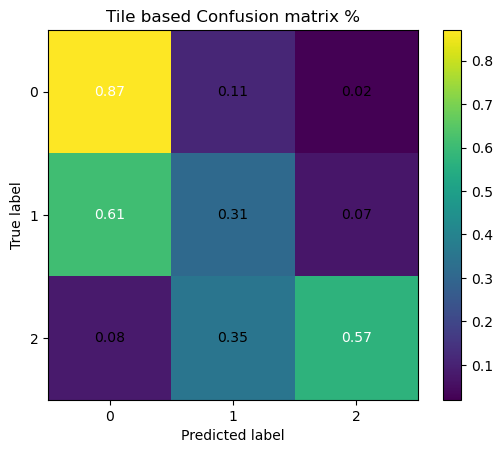

<Figure size 640x480 with 0 Axes>

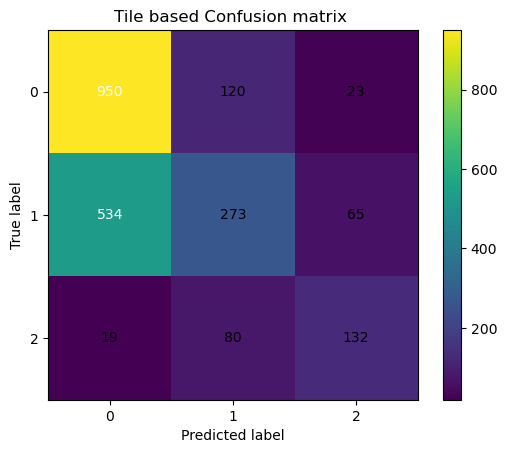

<Figure size 640x480 with 0 Axes>

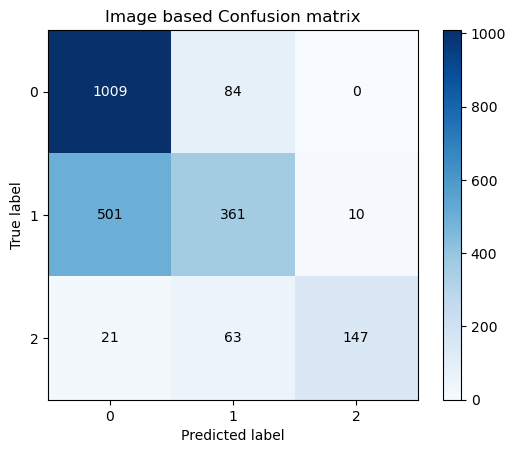

<Figure size 640x480 with 0 Axes>

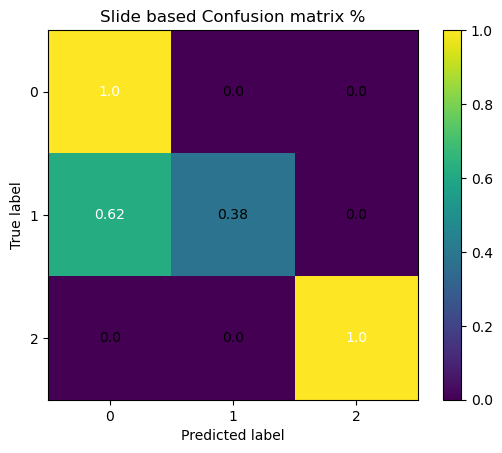

<Figure size 640x480 with 0 Axes>

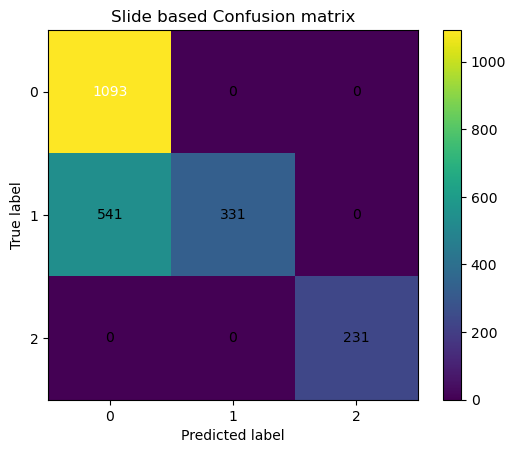

dict_keys(['slide17', 'slide18', 'slide19', 'slide20', 'Slide10', 'Slide13', 'Slide5', 'Slide6', 'Slide7', 'Slide8', 'Slide30', 'Slide31', 'Slide32', 'Slide42', 'slide41'])


<Figure size 640x480 with 0 Axes>

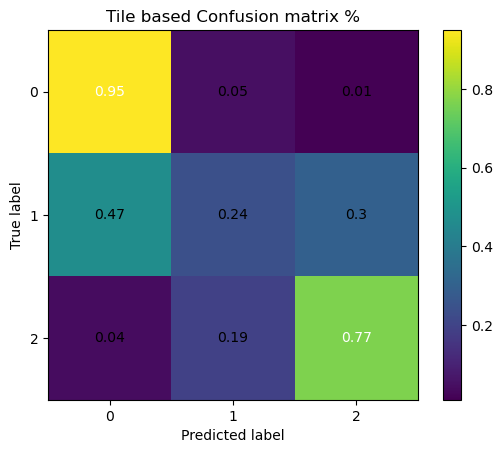

<Figure size 640x480 with 0 Axes>

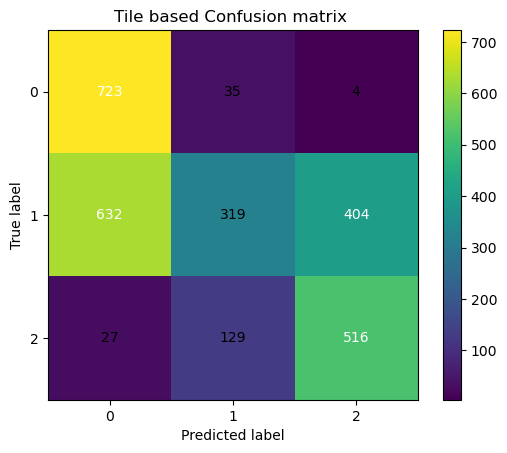

<Figure size 640x480 with 0 Axes>

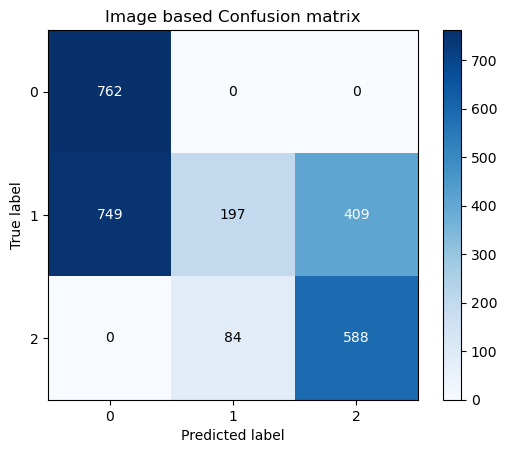

<Figure size 640x480 with 0 Axes>

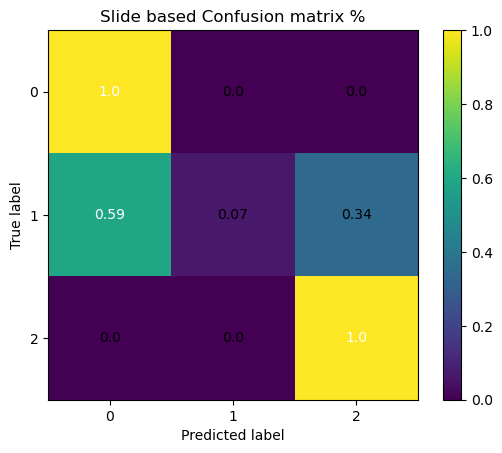

<Figure size 640x480 with 0 Axes>

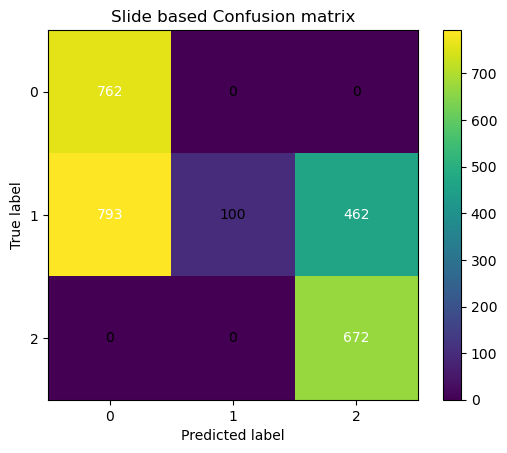

dict_keys(['slide26', 'slide28', 'slide46', 'slide47', 'Slide28', 'Slide34', 'Slide25', 'Slide37', 'Slide38', 'Slide48', 'Slide33', 'Slide39', 'Slide40', 'Slide49', 'Slide43', 'Slide45', 'slide44'])


<Figure size 640x480 with 0 Axes>

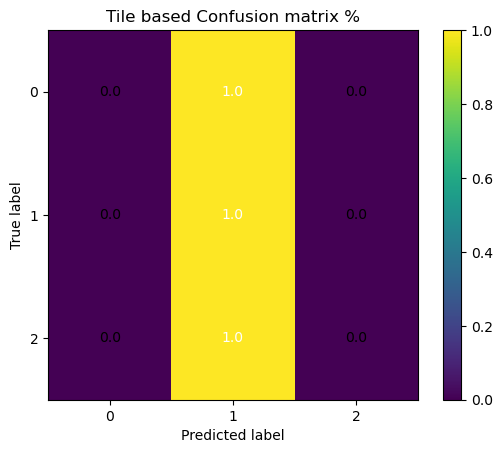

<Figure size 640x480 with 0 Axes>

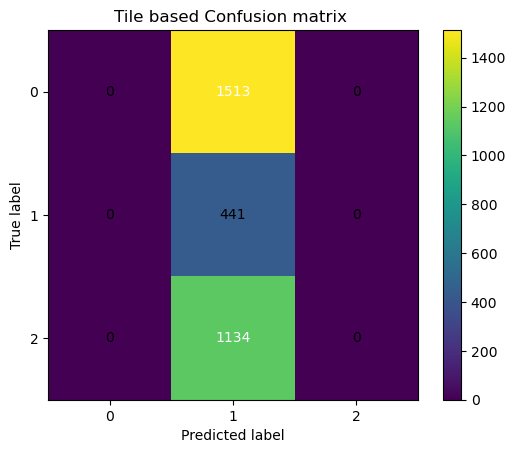

<Figure size 640x480 with 0 Axes>

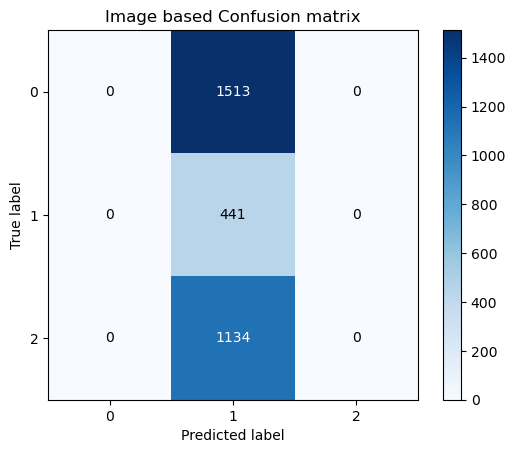

<Figure size 640x480 with 0 Axes>

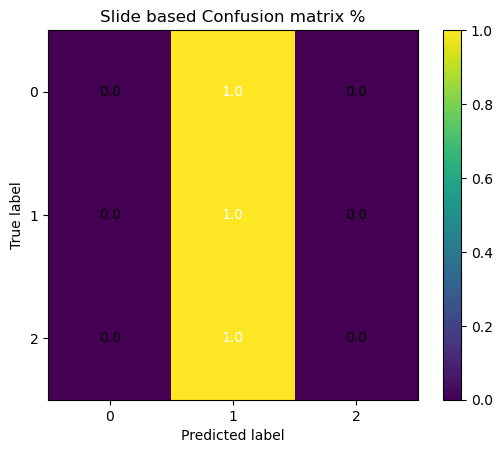

<Figure size 640x480 with 0 Axes>

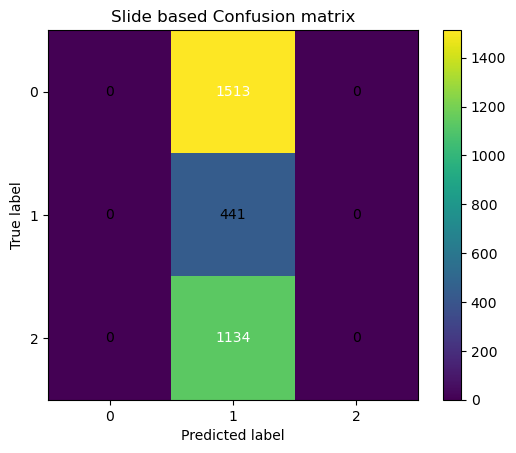

C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\salma\.conda\envs\SalmaEnv\lib\site-packages\sklearn

fold1                         fold2                      \
                 Precision    Recall  F1-score Precision    Recall  F1-score   
Low               0.668911  1.000000  0.801613  0.490032  1.000000  0.657747   
Medium            1.000000  0.379587  0.550291  1.000000  0.073801  0.137457   
High              1.000000  1.000000  1.000000  0.592593  1.000000  0.744186   
Micro_average     0.753643  0.753643  0.753643  0.550018  0.550018  0.550018   
weighted_average  0.835209  0.753643  0.792332  0.762505  0.550018  0.639062   

                     fold3                       Average                      
                 Precision    Recall  F1-score Precision    Recall  F1-score  
Low               0.000000  0.000000       NaN  0.386314  0.666667  0.489169  
Medium            0.142811  1.000000  0.249929  0.714270  0.484463  0.577338  
High              0.000000  0.000000       NaN  0.530864  0.666667  0.591065  
Micro_average     0.142811  0.142811  0.142811  0.482157  0.482157  0.482157  
weighted_average  0.020395  0.142811  0.035693  0.539370  0.482157  0.509161

In [30]:
import glob
import matplotlib.pyplot as plt
import numpy as np


from sklearn.metrics import precision_score, recall_score, f1_score,multilabel_confusion_matrix
from sklearn.metrics import precision_recall_curve
#from sklearn.metrics import plot_precision_recall_curve
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
from scikitplot.metrics import plot_confusion_matrix, plot_roc, plot_precision_recall, plot_precision_recall_curve


validation_slide = ['1st_part','2nd_part','3rd_part']
model_name       = 'vgg_train_conv_min2_min3_Leakyrelu'

tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
##Normalized thresholds
low = (10-(min_score))/(max_score-min_score)
mid = (25-(min_score))/(max_score-min_score)
for val_dir in validation_slide:
    validation_DATA_PATH  = val_dir+'_validation/'
    validation_LABEL_PATH = 'analysed_data/All_samples_group_1_2_3_total_score_Median/'+val_dir+'_val_total_score/validation/validation_newlabels.txt'

  
    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_label = np.zeros((n_v,), int)
    
    ######################################################################################################
    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            #validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
    
############################################################################################################    
    y_pred = []  
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as f:
        for line in f:
            y_pred.append(int(line.split(' ')[1].strip()))  

   ##############################################################################################    
    keys = []
    Slide_dict = {}
    flag_28  = False
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            S_num = str(line.split(' ')[0][0:8])
            if '.' in S_num:
                S_num = S_num.replace('.','')
            if '_' in S_num:
                S_num = S_num.replace('_','')
            if S_num not in keys:
                keys.append(S_num)
                Slide_dict[S_num]=[]

    fout.close()
    #########################################################
    ### Add all scores of tiles to the slide key
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=line.split(' ')[0][0:8]
            if '.' in key_temp:
                key_temp = key_temp.replace('.','')
            if '_' in key_temp:
                key_temp = key_temp.replace('_','')
           
            Slide_dict[key_temp].append(float(line.split(' ')[1].strip()))
    print(Slide_dict.keys())
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_slide = np.ones(len(y_pred))  
    offset = 0
    for k in Slide_dict.keys():
        class_0 = [index for index, element in enumerate(Slide_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Slide_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Slide_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_slide[offset:offset+len(Slide_dict[k])]= majority_vote
        #print(y_pred_slide[offset:offset+len(Slide_dict[k])])
        offset += len(Slide_dict[k])
    ################################################################
    
    ### Add all scores of tiles to the Image name key
    keys = []
    Image_dict = {}
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            I_num = str(line.split('___')[0])
            if I_num not in keys:
                keys.append(I_num)
                Image_dict[I_num]=[]

    fout.close()
    
   
    with open('predict_result_3cv/'+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=str(line.split('___')[0])
            Image_dict[key_temp].append(float(line.split(' ')[1].strip()))

    #print(Image_dict.keys())
    
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_image = np.ones(len(y_pred))  
    offset = 0
    for k in Image_dict.keys():
        class_0 = [index for index, element in enumerate(Image_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Image_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Image_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_image[offset:offset+len(Image_dict[k])]= majority_vote
        #print(y_pred_image[offset:offset+len(Image_dict[k])])
        offset += len(Image_dict[k])

    

    #############################
    my_bins = [0, 1, 2]
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred,labels=my_bins,normalize='true', cmap='viridis')
    plt.title('Tile based Confusion matrix %')
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred,labels=my_bins, cmap='viridis')
    plt.title('Tile based Confusion matrix ')
    
    
    
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_image,labels=my_bins)
    plt.title('Image based Confusion matrix')
    
    
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_slide,labels=my_bins,normalize='true', cmap='viridis')
    plt.title('Slide based Confusion matrix %')
    plt.figure()
    plot_confusion_matrix(precise_scores, y_pred_slide,labels=my_bins, cmap='viridis')
    plt.title('Slide based Confusion matrix')
    
    plt.show()

    
    
    

    tile_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','weighted_average'],
                                               columns=['Precision','Recall','F1-score'])
   #############################
    prec_col = np.zeros((1,5))
    tile_classes = precision_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = precision_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = precision_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    tile_weighted = precision_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = tile_classes
    prec_col[0,3] = tile_Micro
    #prec_col[0,4] = tile_Macro
    prec_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    #############################
    rec_col = np.zeros((1,5))
    tile_classes = recall_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = recall_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = recall_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    tile_weighted = recall_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    rec_col[0,0:3] = tile_classes
    rec_col[0,3] = tile_Micro
    #rec_col[0,4] = tile_Macro
    rec_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #############################
     #############################
    f1_score_col = np.zeros((1,5))
    tile_classes = f1_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    tile_Micro = f1_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = f1_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    tile_weighted =  f1_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    f1_score_col[0,0:3] = tile_classes
    f1_score_col[0,3] = tile_Micro
    #f1_score_col[0,4] = tile_Macro
    f1_score_col[0,4] = tile_weighted
    tile_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
    #############################
#################################################################################################################    
       #############################

    #############################
#################################################################################################################    
    image_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','Macro_average','weighted_average'],columns=['Precision','Recall','F1-score','support'])
   #############################
    prec_col = np.zeros((1,6))
    image_classes = precision_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = precision_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = precision_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted = precision_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = image_classes
    prec_col[0,3] = image_Micro
    prec_col[0,4] = image_Macro
    prec_col[0,5] = image_weighted
    image_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    #############################
    rec_col = np.zeros((1,6))
    image_classes = recall_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = recall_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = recall_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted = recall_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    rec_col[0,0:3] = image_classes
    rec_col[0,3] = image_Micro
    rec_col[0,4] = image_Macro
    rec_col[0,5] = image_weighted
    image_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #############################
     #############################
    f1_score_col = np.zeros((1,6))
    image_classes = f1_score(precise_scores,y_pred_image, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    image_Micro = f1_score(precise_scores,y_pred_image, sample_weight=None,average='micro', zero_division='warn')
    image_Macro = f1_score(precise_scores,y_pred_image, sample_weight=None,average='macro', zero_division='warn')
    image_weighted =  f1_score(precise_scores,y_pred_image, sample_weight=None,average='weighted', zero_division='warn')
    
    f1_score_col[0,0:3] = image_classes
    f1_score_col[0,3] = image_Micro
    f1_score_col[0,4] = image_Macro
    f1_score_col[0,5] = image_weighted
    f1_score_col = (prec_col*rec_col*2) / (prec_col+rec_col)
    image_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
    #############################
#################################################################################################################    
    supprt_col = np.zeros((1,6))
    image_class0 = np.sum(np.array(precise_scores) == 0)
    image_class1 = np.sum(np.array(precise_scores) == 1)
    image_class2 = np.sum(np.array(precise_scores) == 2)
    
    image_Micro    = len(precise_scores)
    image_Macro    = len(precise_scores)
    image_weighted = len(precise_scores)
    
    supprt_col[0,0] = image_class0
    supprt_col[0,1] = image_class1
    supprt_col[0,2] = image_class2
    
    supprt_col[0,3] = image_Micro
    supprt_col[0,4] = image_Macro
    supprt_col[0,5] = image_weighted
    image_based_scores[val_dir]['support']  =  supprt_col.transpose()
    
    
    #############################
    slide_based_scores[val_dir]  = pd.DataFrame(data=None, index=['Low','Medium','High','Micro_average','weighted_average'],
                                                columns=['Precision','Recall','F1-score'])
   #############################
    prec_col = np.zeros((1,5))
    slide_classes = precision_score(precise_scores,y_pred_slide, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    slide_Micro = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='micro', zero_division='warn')
    #slide_Macro = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='macro', zero_division='warn')
    slide_weighted = precision_score(precise_scores,y_pred_slide, sample_weight=None,average='weighted', zero_division='warn')
    
    prec_col[0,0:3] = slide_classes
    prec_col[0,3] = slide_Micro
    #prec_col[0,4] = slide_Macro
    prec_col[0,4] = slide_weighted
    slide_based_scores[val_dir]['Precision']  = prec_col.transpose()
    #############################
    #############################
    rec_col = np.zeros((1,5))
    slide_classes = recall_score(precise_scores,y_pred_slide, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    slide_Micro = recall_score(precise_scores,y_pred_slide, sample_weight=None,average='micro', zero_division='warn')
    #slide_Macro = recall_score(precise_scores,y_pred_slide, sample_weight=None,average='macro', zero_division='warn')
    slide_weighted = recall_score(precise_scores,y_pred_slide,average='weighted', zero_division='warn')
    
    rec_col[0,0:3] = slide_classes
    rec_col[0,3] = slide_Micro
    #rec_col[0,4] = slide_Macro
    rec_col[0,4] = slide_weighted
    slide_based_scores[val_dir]['Recall']  = rec_col.transpose()
    #############################
    f1_score_col = np.zeros((1,5))
    #slide_classes = f1_score(precise_scores,y_pred, labels=my_bins, sample_weight=None,average=None, zero_division='warn')
    #slide_Micro = f1_score(precise_scores,y_pred, sample_weight=None,average='micro', zero_division='warn')
    #tile_Macro = f1_score(precise_scores,y_pred, sample_weight=None,average='macro', zero_division='warn')
    #slide_weighted =  f1_score(precise_scores,y_pred, sample_weight=None,average='weighted', zero_division='warn')
    
    #f1_score_col[0,0:3] = slide_classes
    #f1_score_col[0,3] = slide_Micro
    #f1_score_col[0,4] = tile_Macro
    #f1_score_col[0,4] = slide_weighted
    f1_score_col = (prec_col*rec_col*2) / (prec_col+rec_col)
    slide_based_scores[val_dir]['F1-score']  =  f1_score_col.transpose()
     #############################
        #############################
#################################################################################################################    
 ################################################################################################
df_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part']], axis=1,
                     keys=['fold1','fold2','fold3'])

df_img  = pd.concat([image_based_scores['1st_part'], image_based_scores['2nd_part'],image_based_scores['3rd_part']], axis=1,
                     keys=['fold1','fold2','fold3'])

df_slide  = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part']], axis=1,
                       keys=['fold1','fold2','fold3'])

#################################################################################################

df_1_tile = np.array(df_tile.iloc[0:6,0:3]).astype(float)
df_2_tile = np.array(df_tile.iloc[0:6,3:6]).astype(float)
df_3_tile = np.array(df_tile.iloc[0:6,6:9]).astype(float)





a = [df_1_tile,df_2_tile,df_3_tile]



tile_mean = np.mean(a,axis=0)


tile_m = pd.DataFrame(tile_mean,columns= ['Precision','Recall','F1-score'],index = ['Low','Medium','High','Micro_average','weighted_average'])
tile_m


tile_m['F1-score'] = (2*tile_m['Precision']*tile_m['Recall'])/(tile_m['Precision']+tile_m['Recall'])

tile_m
############################################################################################


df_1_img = np.array(df_img.iloc[0:7,0:3]).astype(float)
df_2_img = np.array(df_img.iloc[0:7,4:7]).astype(float)
df_3_img = np.array(df_img.iloc[0:7,8:11]).astype(float)


weights_1 = np.array(df_img.iloc[0:7,3]).astype(float)*np.identity(6)
weights_2 = np.array(df_img.iloc[0:7,7]).astype(float)*np.identity(6)
weights_3 = np.array(df_img.iloc[0:7,11]).astype(float)*np.identity(6)

sum_weights = np.matmul((weights_1+weights_2+weights_3),np.ones([6,1]))



b = [np.matmul(weights_1/sum_weights,df_1_img),np.matmul(weights_2/sum_weights,df_2_img),
    np.matmul(weights_3/sum_weights,df_3_img)]


img_mean = np.sum(b,axis=0)
img_m = pd.DataFrame(img_mean,columns= ['precision','recall','f1-score'],index = ['Low','Medium','High','Micro_average','Macro_average','weighted_average'])
img_m

###################################################################################################

#df_1_slide = np.array(df_slide.iloc[0:6,0:2]).astype(float)
#df_2_slide = np.array(df_slide.iloc[0:6,2:4]).astype(float)
#df_3_slide = np.array(df_slide.iloc[0:6,4:6]).astype(float)

df_1_slide = np.array(df_slide.iloc[0:6,0:3]).astype(float)
df_2_slide = np.array(df_slide.iloc[0:6,3:6]).astype(float)
df_3_slide = np.array(df_slide.iloc[0:6,6:9]).astype(float)





a = [df_1_slide,df_2_slide,df_3_slide]



slide_mean = np.mean(a,axis=0)
slide_m = pd.DataFrame(slide_mean,columns= ['Precision','Recall','F1-score'],
                       index = ['Low','Medium','High','Micro_average','weighted_average'])

slide_m['F1-score'] = (2*slide_m['Precision']*slide_m['Recall'])/(slide_m['Precision']+slide_m['Recall'])


#df_vgg_man_aug_tile = pd.concat([df_tile['fold1'],df_tile['fold2'],df_tile['fold3'],tile_m],axis=1,keys=['fold1,fold2,fold3','Average'])
#df_vgg_man_aug_tile
df_vgg_train_conv_min2_min3_LeakyReLU_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part'],tile_m], axis=1,keys=['fold1','fold2','fold3','Average'])
df_vgg_train_conv_min2_min3_LeakyReLU_tile

df_vgg_train_conv_min2_min3_LeakyReLU_slide  = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part'],slide_m], axis=1,keys=['fold1','fold2','fold3','Average'])
df_vgg_train_conv_min2_min3_LeakyReLU_slide



In [6]:
from numba import cuda

device = cuda.get_current_device()
print(device)
device.reset()



<CUDA device 0 'b'NVIDIA GeForce RTX 2060''>
